# Diagnosing Short-Range Fit Failures in the CO₂–H₂ PES

**Purpose.** This notebook diagnoses why sparse short-range fits, especially near **R = 4.4 Bohr**, produce local angular oscillations and large angular derivatives. The main question is whether the failures come from the 158-term angular basis, the switching/scaling function, the least-squares procedure, or the distribution of sampled angular points.

**Working interpretation.** The 158-term basis appears usable when it is sufficiently constrained. The main short-range difficulty is that a uniform angular grid puts many points in very high-energy, physically inaccessible configurations, while leaving relatively few points in the energy range that matters for scattering. This makes sparse global fits unstable and makes the switching function an important but imperfect patch.

The notebook is organized as a diagnostic story:

1. Show the short-range oscillation problem.
2. Quantify how sparse sampling affects angular forces.
3. Test whether basis truncation is a real solution or just hard regularization.
4. Check the design matrix directly using singular values and condition numbers.
5. Sweep the number of points and radial distance to see where the fit becomes stable.
6. Test weighting, switching, and regularization alternatives.
7. End with dense-grid baselines that clarify what the full basis can do when it has enough information.


## Cell 1 — Setup: basis, switching function, and shared helpers

This cell defines the 158-term basis used throughout the notebook, loads the ab initio data, applies the current switching function, and defines small helper functions used by the later diagnostics.

The switching function used here is the existing baseline. Later cells test whether this scaling is helping or distorting the short-range fit.


In [1]:
import math
import warnings
from functools import lru_cache
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.special import lpmv
from sympy.physics.wigner import wigner_3j

warnings.filterwarnings("ignore")

DATA_FILE = Path("all_avcbs_uniform.dat")
LSTSQ_RCOND = 1e-4

# Current switching thresholds used in the baseline workflow.
SWITCH_T1 = 1000.0
SWITCH_T2 = 5000.0


@lru_cache(maxsize=None)
def cached_wigner_3j(l1, l2, l, m1, m2, m3):
    """Cache Wigner 3-j values; repeated basis evaluations otherwise become slow."""
    return float(wigner_3j(l1, l2, l, m1, m2, m3))


def generate_basis_indices():
    """Generate the 158 angular basis triplets used in the CO2-H2 expansion."""
    basis = []
    for l1 in range(0, 25, 2):
        for l2 in range(0, 7, 2):
            if l1 >= 22 and l2 > 0:
                continue
            for l in range(abs(l1 - l2), l1 + l2 + 1):
                if (l1 + l2 + l) % 2 == 0:
                    basis.append((l1, l2, l))
    return basis


basis_indices = generate_basis_indices()
print(f"Loaded physical basis terms: {len(basis_indices)} (expected 158)")


def evaluate_A_basis(l1, l2, l, theta1_rad, theta2_rad, phi_rad):
    """Evaluate one angular basis function on vectorized angle arrays."""
    cos_t1 = np.cos(theta1_rad)
    cos_t2 = np.cos(theta2_rad)

    wj_zero = cached_wigner_3j(l1, l2, l, 0, 0, 0)
    p_l1_0 = np.sqrt((2 * l1 + 1) / 2.0) * lpmv(0, l1, cos_t1)
    p_l2_0 = np.sqrt((2 * l2 + 1) / 2.0) * lpmv(0, l2, cos_t2)
    total = ((-1) ** (l1 - l2)) * wj_zero * p_l1_0 * p_l2_0

    for m in range(1, min(l1, l2) + 1):
        wj_m = cached_wigner_3j(l1, l2, l, m, -m, 0)
        norm1 = np.sqrt(((2 * l1 + 1) / 2.0) * math.factorial(l1 - m) / math.factorial(l1 + m))
        norm2 = np.sqrt(((2 * l2 + 1) / 2.0) * math.factorial(l2 - m) / math.factorial(l2 + m))
        p_l1 = norm1 * lpmv(m, l1, cos_t1)
        p_l2 = norm2 * lpmv(m, l2, cos_t2)
        total += 2.0 * ((-1) ** (m + l1 - l2)) * wj_m * p_l1 * p_l2 * np.cos(m * phi_rad)

    return np.sqrt((2 * l + 1) / (4.0 * np.pi)) * total


def apply_switching_function(V_raw, V_T1=SWITCH_T1, V_T2=SWITCH_T2):
    """Apply the current short-range energy scaling used in the baseline fit."""
    V_raw = np.asarray(V_raw, dtype=float)
    V_scaled = np.empty_like(V_raw)

    below = V_raw <= V_T1
    above = V_raw > V_T2
    middle = ~(below | above)

    V_scaled[below] = V_raw[below]
    V_scaled[above] = V_T1 + (2.0 / np.pi) * (V_T2 - V_T1)

    u = (V_raw[middle] - V_T1) / (V_T2 - V_T1)
    S_u = (2.0 / np.pi) * np.sin((np.pi / 2.0) * np.sin((np.pi / 2.0) * u))
    V_scaled[middle] = V_T1 + (V_T2 - V_T1) * S_u
    return V_scaled


def angles_from_df(df):
    """Return angle columns in radians."""
    return (
        np.radians(df["Theta_1"].values),
        np.radians(df["Theta_2"].values),
        np.radians(df["Phi"].values),
    )


def build_design_matrix(df_or_t1, basis, t2=None, phi=None):
    """Build the least-squares design matrix for a DataFrame or angle arrays."""
    if isinstance(df_or_t1, pd.DataFrame):
        t1, t2, phi = angles_from_df(df_or_t1)
    else:
        t1 = df_or_t1
        if t2 is None or phi is None:
            raise ValueError("Provide t2 and phi when passing angle arrays directly.")

    M = np.empty((len(t1), len(basis)))
    for idx, (l1, l2, l) in enumerate(basis):
        M[:, idx] = evaluate_A_basis(l1, l2, l, t1, t2, phi)
    return M


def fit_coefficients(df_train, basis, target_col="V_scaled", rcond=LSTSQ_RCOND):
    """Fit basis coefficients by least squares and return (coefficients, design matrix)."""
    M_train = build_design_matrix(df_train, basis)
    coeffs, *_ = np.linalg.lstsq(M_train, df_train[target_col].values, rcond=rcond)
    return coeffs, M_train


def predict_from_df(df_eval, basis, coeffs):
    """Evaluate a fitted expansion on a DataFrame of angular points."""
    return build_design_matrix(df_eval, basis) @ coeffs


def svd_rank_and_condition(M, rank_tol=1e-3):
    """Return effective rank, condition number, and singular values."""
    singular_values = np.linalg.svd(M, full_matrices=False, compute_uv=False)
    rank = int(np.sum(singular_values > rank_tol))
    cond = singular_values[0] / singular_values[-1] if singular_values[-1] > 0 else np.inf
    return rank, cond, singular_values


def relative_error_percent(pred, truth, floor=1e-2):
    """Relative error with a small denominator floor near zero crossings."""
    denom = np.maximum(np.abs(truth), floor)
    return np.abs(pred - truth) / denom * 100.0


def get_r_slice(df, target_R):
    """Return a copy of one radial slice."""
    return df[df["R"] == target_R].copy()


# Load data. The notebook assumes the data file is in the same directory.
df_all = pd.read_csv(
    DATA_FILE,
    sep=r"\s+",
    names=["R", "Theta_1", "Theta_2", "Phi", "V"],
)
df_all["V_scaled"] = apply_switching_function(df_all["V"].values)

print(f"Loaded {len(df_all):,} ab initio points across {df_all['R'].nunique()} radial slices.")


Loaded physical basis terms: 158 (expected 158)
Loaded 15,000 ab initio points across 30 radial slices.


## Cell 2 — Visualizing the short-range data gaps

This first diagnostic compares a dense fit using all 500 angular points at **R = 4.4 Bohr** with a sparse fit using only **N = 165** randomly selected points.

The point of this plot is not to prove the whole argument. It shows the failure mode: when a flexible global basis is fit with a nearly one-to-one data-to-parameter ratio, it can wiggle between sparse training points even if it still passes near the sampled data.


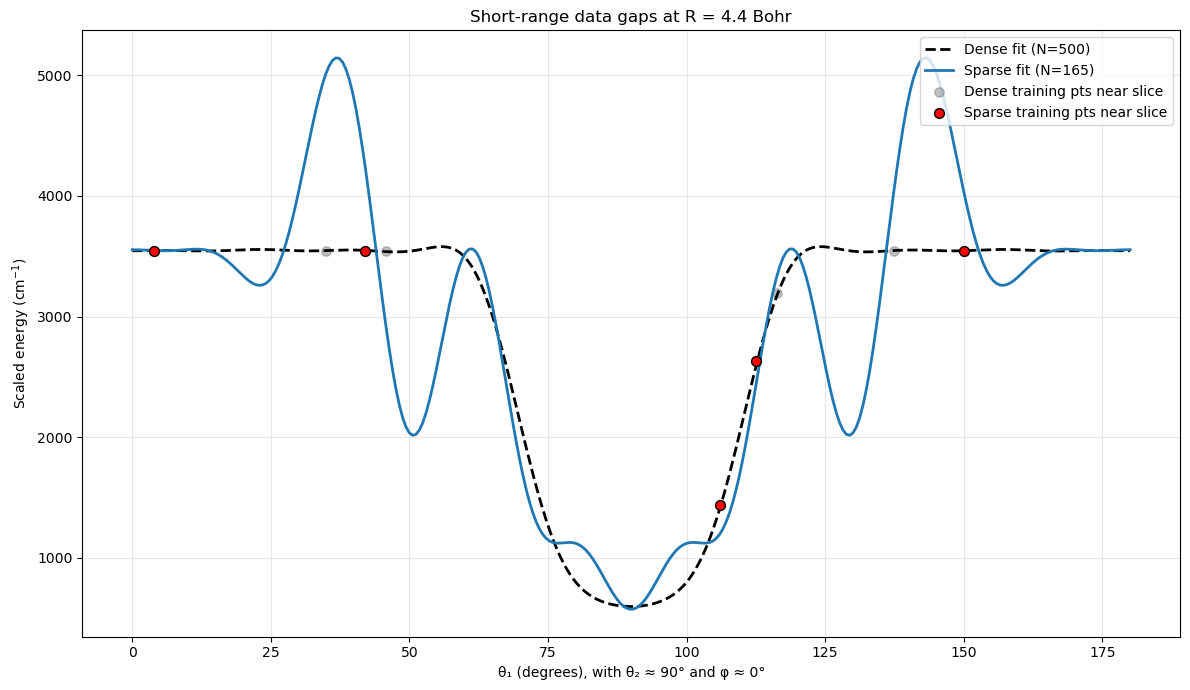

In [2]:
def plot_diagnostic_r44_scatter(df, basis, target_R=4.40, keep_N=165):
    df_r = get_r_slice(df, target_R)
    df_sparse = df_r.sample(n=keep_N, random_state=42)

    coeffs_dense, _ = fit_coefficients(df_r, basis, target_col="V_scaled")
    coeffs_sparse, _ = fit_coefficients(df_sparse, basis, target_col="V_scaled")

    sweep_angles = np.linspace(0, 180, 300)
    t1_sweep = np.radians(sweep_angles)
    t2_sweep = np.full_like(t1_sweep, np.radians(90.0))
    phi_sweep = np.full_like(t1_sweep, np.radians(0.0))
    M_sweep = build_design_matrix(t1_sweep, basis, t2_sweep, phi_sweep)

    pred_dense = M_sweep @ coeffs_dense
    pred_sparse = M_sweep @ coeffs_sparse

    t1_dense, t2_dense, phi_dense = angles_from_df(df_r)
    t1_sparse, t2_sparse, phi_sparse = angles_from_df(df_sparse)

    near_dense = (np.abs(np.degrees(t2_dense) - 90.0) < 15) & (np.abs(np.degrees(phi_dense)) < 15)
    near_sparse = (np.abs(np.degrees(t2_sparse) - 90.0) < 15) & (np.abs(np.degrees(phi_sparse)) < 15)

    fig, ax = plt.subplots(figsize=(12, 7))
    ax.plot(sweep_angles, pred_dense, color="black", linestyle="--", linewidth=2, label="Dense fit (N=500)")
    ax.plot(sweep_angles, pred_sparse, color="tab:blue", linewidth=2, label=f"Sparse fit (N={keep_N})")

    ax.scatter(np.degrees(t1_dense)[near_dense], df_r["V_scaled"].values[near_dense],
               color="gray", s=45, alpha=0.5, label="Dense training pts near slice")
    ax.scatter(np.degrees(t1_sparse)[near_sparse], df_sparse["V_scaled"].values[near_sparse],
               color="red", s=50, zorder=5, edgecolor="black", label="Sparse training pts near slice")

    ax.set_title(f"Short-range data gaps at R = {target_R} Bohr")
    ax.set_xlabel("θ₁ (degrees), with θ₂ ≈ 90° and φ ≈ 0°")
    ax.set_ylabel("Scaled energy (cm$^{-1}$)")
    ax.grid(True, alpha=0.3)
    ax.legend(loc="upper right")
    plt.tight_layout()
    plt.show()


plot_diagnostic_r44_scatter(df_all, basis_indices)


## Cell 3 — Sparse-grid variance and angular force

The visual wiggles matter because their derivatives can become large. This cell checks two things at **R = 4.4 Bohr**:

1. How many of the 500 available points enter the current switching/capping regime.
2. Whether increasing the sparse sample from **N = 165** to **N = 250** reduces trial-to-trial variation and maximum angular force.

The important interpretation is not that lower angular force is always physically better. Rather, if the maximum derivative drops substantially when more points are added, then some of the large forces in the sparse fit are likely numerical artifacts.


=== Sparse-grid variance audit at R = 4.4 Bohr ===

[Energy profile of the full 500-point grid]
  Total points: 500
  Points > 1000 cm^-1: 487 (97.4%)
  Points > 5000 cm^-1: 321 (64.2%)

[Random sparse fits: N = 165]
  Max angular forces: [np.float64(24252.5), np.float64(14955.3), np.float64(14508.2), np.float64(19016.3), np.float64(28772.8)]
  Mean max force: 20301.0 cm^-1/rad

[Random sparse fits: N = 250]
  Max angular forces: [np.float64(10857.8), np.float64(11286.9), np.float64(10803.7), np.float64(11315.6), np.float64(12104.9)]
  Mean max force: 11273.8 cm^-1/rad


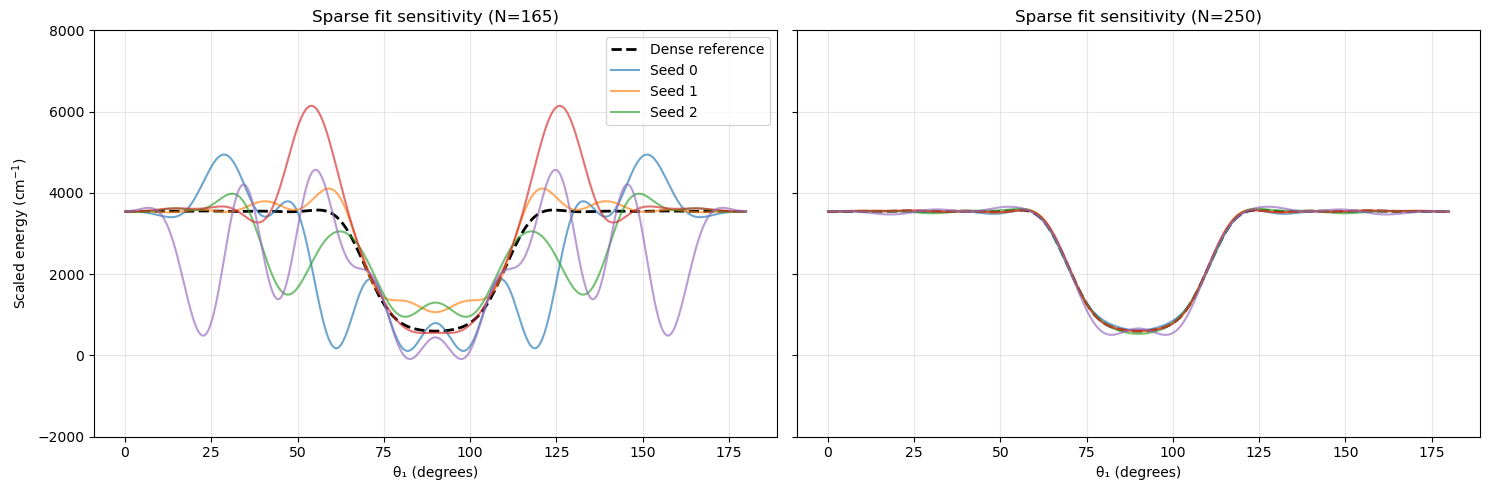

In [3]:
def interrogate_short_range_failures(df, basis, target_R=4.40, n_trials=5, sample_sizes=(165, 250)):
    print(f"=== Sparse-grid variance audit at R = {target_R} Bohr ===")
    df_r = get_r_slice(df, target_R)
    V_raw = df_r["V"].values

    n_total = len(df_r)
    n_above_T1 = int(np.sum(V_raw > SWITCH_T1))
    n_above_T2 = int(np.sum(V_raw > SWITCH_T2))
    print("\n[Energy profile of the full 500-point grid]")
    print(f"  Total points: {n_total}")
    print(f"  Points > {SWITCH_T1:.0f} cm^-1: {n_above_T1} ({100*n_above_T1/n_total:.1f}%)")
    print(f"  Points > {SWITCH_T2:.0f} cm^-1: {n_above_T2} ({100*n_above_T2/n_total:.1f}%)")

    # Dense reference curve on the same 1D angular sweep as Cell 2.
    coeffs_dense, _ = fit_coefficients(df_r, basis, target_col="V_scaled")
    sweep_angles = np.linspace(0, 180, 300)
    t1_sweep = np.radians(sweep_angles)
    t2_sweep = np.full_like(t1_sweep, np.radians(90.0))
    phi_sweep = np.full_like(t1_sweep, np.radians(0.0))
    M_sweep = build_design_matrix(t1_sweep, basis, t2_sweep, phi_sweep)
    dense_sweep = M_sweep @ coeffs_dense

    fig, axes = plt.subplots(1, len(sample_sizes), figsize=(15, 5), sharey=True)
    if len(sample_sizes) == 1:
        axes = [axes]

    for ax, N in zip(axes, sample_sizes):
        print(f"\n[Random sparse fits: N = {N}]")
        max_forces = []
        ax.plot(sweep_angles, dense_sweep, color="black", linestyle="--", linewidth=2, label="Dense reference")

        for seed in range(n_trials):
            df_train = df_r.sample(n=N, random_state=seed)
            coeffs, _ = fit_coefficients(df_train, basis, target_col="V_scaled")
            pred_sweep = M_sweep @ coeffs
            max_force = np.max(np.abs(np.gradient(pred_sweep, t1_sweep)))
            max_forces.append(max_force)
            ax.plot(sweep_angles, pred_sweep, alpha=0.65, label=f"Seed {seed}" if seed < 3 else None)

        print(f"  Max angular forces: {[round(f, 1) for f in max_forces]}")
        print(f"  Mean max force: {np.mean(max_forces):.1f} cm^-1/rad")

        ax.set_title(f"Sparse fit sensitivity (N={N})")
        ax.set_xlabel("θ₁ (degrees)")
        ax.grid(True, alpha=0.3)
        ax.set_ylim(-2000, 8000)

    axes[0].set_ylabel("Scaled energy (cm$^{-1}$)")
    axes[0].legend(loc="upper right")
    plt.tight_layout()
    plt.show()


interrogate_short_range_failures(df_all, basis_indices)


## Cell 4 — Basis truncation as hard regularization

This cell tests whether the full 158-term basis is simply too flexible for **N = 165**. The truncated basis keeps only terms with **l₁ ≤ 10** and **l₂ ≤ 4**, reducing the basis from 158 terms to 46 terms.

This is best interpreted as a diagnostic, not as a proposed final solution. Truncation can suppress sparse-data variance, but it may also remove real short-range angular structure, especially because both rotors can matter strongly at short distance.


=== Basis truncation diagnostic at R = 4.4 Bohr ===
Full basis terms: 158
Truncated basis terms: 46
Data/parameter ratio, full basis: 1.04
Data/parameter ratio, truncated basis: 3.59

Max angular force, sparse full basis: 20794.8 cm^-1/rad
Max angular force, sparse truncated basis: 6847.0 cm^-1/rad


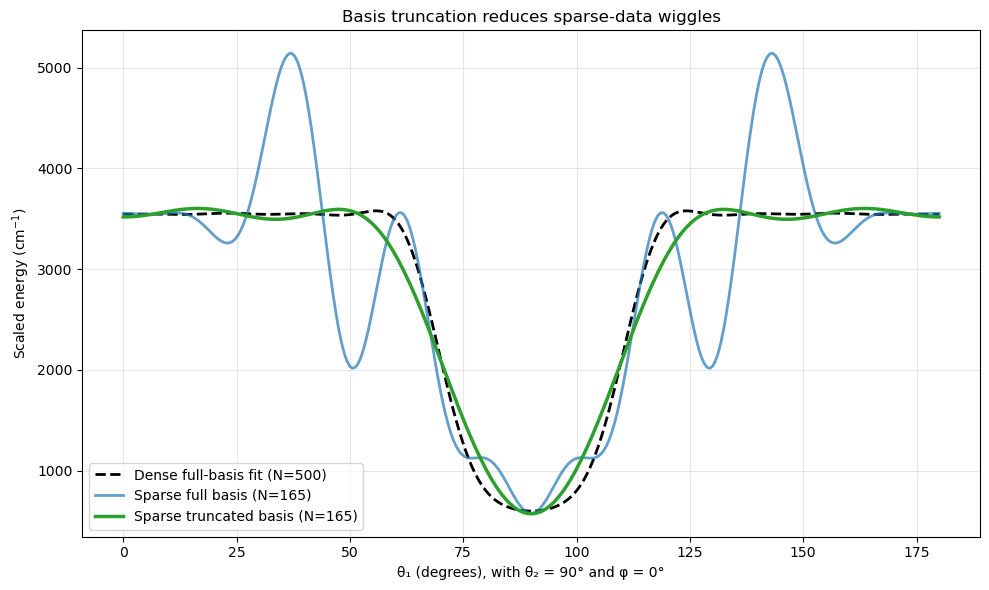

In [4]:
def truncated_basis(full_basis, max_l1=10, max_l2=4):
    return [(l1, l2, l) for (l1, l2, l) in full_basis if l1 <= max_l1 and l2 <= max_l2]


def test_basis_truncation(df, full_basis, target_R=4.40, keep_N=165):
    df_r = get_r_slice(df, target_R)
    df_sparse = df_r.sample(n=keep_N, random_state=42)
    basis_trunc = truncated_basis(full_basis)

    print(f"=== Basis truncation diagnostic at R = {target_R} Bohr ===")
    print(f"Full basis terms: {len(full_basis)}")
    print(f"Truncated basis terms: {len(basis_trunc)}")
    print(f"Data/parameter ratio, full basis: {keep_N / len(full_basis):.2f}")
    print(f"Data/parameter ratio, truncated basis: {keep_N / len(basis_trunc):.2f}")

    coeffs_dense, _ = fit_coefficients(df_r, full_basis, target_col="V_scaled")
    coeffs_global, _ = fit_coefficients(df_sparse, full_basis, target_col="V_scaled")
    coeffs_trunc, _ = fit_coefficients(df_sparse, basis_trunc, target_col="V_scaled")

    sweep_angles = np.linspace(0, 180, 300)
    t1_sweep = np.radians(sweep_angles)
    t2_sweep = np.full_like(t1_sweep, np.radians(90.0))
    phi_sweep = np.full_like(t1_sweep, np.radians(0.0))

    pred_dense = build_design_matrix(t1_sweep, full_basis, t2_sweep, phi_sweep) @ coeffs_dense
    pred_global = build_design_matrix(t1_sweep, full_basis, t2_sweep, phi_sweep) @ coeffs_global
    pred_trunc = build_design_matrix(t1_sweep, basis_trunc, t2_sweep, phi_sweep) @ coeffs_trunc

    force_global = np.max(np.abs(np.gradient(pred_global, t1_sweep)))
    force_trunc = np.max(np.abs(np.gradient(pred_trunc, t1_sweep)))
    print(f"\nMax angular force, sparse full basis: {force_global:.1f} cm^-1/rad")
    print(f"Max angular force, sparse truncated basis: {force_trunc:.1f} cm^-1/rad")

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.plot(sweep_angles, pred_dense, color="black", linestyle="--", linewidth=2, label="Dense full-basis fit (N=500)")
    ax.plot(sweep_angles, pred_global, color="tab:blue", linewidth=2, alpha=0.7, label="Sparse full basis (N=165)")
    ax.plot(sweep_angles, pred_trunc, color="tab:green", linewidth=2.5, label="Sparse truncated basis (N=165)")
    ax.set_title("Basis truncation reduces sparse-data wiggles")
    ax.set_xlabel("θ₁ (degrees), with θ₂ = 90° and φ = 0°")
    ax.set_ylabel("Scaled energy (cm$^{-1}$)")
    ax.grid(True, alpha=0.3)
    ax.legend()
    plt.tight_layout()
    plt.show()


test_basis_truncation(df_all, basis_indices)


## Cell 5 — Out-of-sample test: full basis vs truncated basis

The previous cell showed that truncation suppresses wiggles. This cell asks whether that improvement also appears in held-out error metrics at **N = 165**.

The important nuance: if the truncated basis outperforms the full basis under sparse sampling, that does **not** prove the truncated basis is more physical. It may simply mean the full basis is underconstrained at this point density.


In [5]:
def evaluate_truncation_generalization_multiseed(df, full_basis, target_R=4.40, keep_N=165, n_trials=5):
    print(f"=== Full vs truncated basis generalization ({n_trials} trials, R = {target_R}) ===")
    print("Metrics evaluate only held-out points with raw V < 5000 cm^-1.\n")

    df_r = get_r_slice(df, target_R)
    basis_trunc = truncated_basis(full_basis)
    seeds = [42 + 13*i for i in range(n_trials)]

    metrics = {"global_rmse": [], "global_max": [], "trunc_rmse": [], "trunc_max": []}

    for seed in seeds:
        df_train = df_r.sample(n=keep_N, random_state=seed)
        df_test = df_r.drop(df_train.index)
        mask = df_test["V"].values < 5000.0

        coeffs_global, _ = fit_coefficients(df_train, full_basis, target_col="V_scaled")
        coeffs_trunc, _ = fit_coefficients(df_train, basis_trunc, target_col="V_scaled")

        y_true = df_test["V_scaled"].values
        pred_global = predict_from_df(df_test, full_basis, coeffs_global)
        pred_trunc = predict_from_df(df_test, basis_trunc, coeffs_trunc)

        err_global = pred_global[mask] - y_true[mask]
        err_trunc = pred_trunc[mask] - y_true[mask]

        metrics["global_rmse"].append(np.sqrt(np.mean(err_global**2)))
        metrics["global_max"].append(np.max(np.abs(err_global)))
        metrics["trunc_rmse"].append(np.sqrt(np.mean(err_trunc**2)))
        metrics["trunc_max"].append(np.max(np.abs(err_trunc)))

    print(f"{'Model':<24} | {'RMSE (cm^-1)':<22} | {'Max abs err (cm^-1)':<24}")
    print("-" * 78)
    print(f"{'Full 158-term basis':<24} | {np.mean(metrics['global_rmse']):.2f} ± {np.std(metrics['global_rmse']):.2f} | {np.mean(metrics['global_max']):.2f} ± {np.std(metrics['global_max']):.2f}")
    print(f"{'Truncated 46-term basis':<24} | {np.mean(metrics['trunc_rmse']):.2f} ± {np.std(metrics['trunc_rmse']):.2f} | {np.mean(metrics['trunc_max']):.2f} ± {np.std(metrics['trunc_max']):.2f}")


evaluate_truncation_generalization_multiseed(df_all, basis_indices)


=== Full vs truncated basis generalization (5 trials, R = 4.4) ===
Metrics evaluate only held-out points with raw V < 5000 cm^-1.

Model                    | RMSE (cm^-1)           | Max abs err (cm^-1)     
------------------------------------------------------------------------------
Full 158-term basis      | 453.12 ± 380.72 | 2302.44 ± 2002.02
Truncated 46-term basis  | 112.75 ± 16.98 | 412.79 ± 83.80


## Cell 6 — Matrix health and the information limit

This cell checks the design matrix directly. The dense 500-point matrix can resolve all 158 basis directions, while a 165-point random subset is nearly singular in some directions.

This is the linear-algebra version of the same story: the sparse grid does not contain enough information to constrain the full basis reliably at **R = 4.4 Bohr**.


In [6]:
def audit_matrix_information_limit(df, basis, target_R=4.40, keep_N=165):
    print(f"=== Matrix information audit at R = {target_R} Bohr ===")
    df_r = get_r_slice(df, target_R)
    df_sparse = df_r.sample(n=keep_N, random_state=42)

    M_dense = build_design_matrix(df_r, basis)
    M_sparse = build_design_matrix(df_sparse, basis)
    _, _, S_dense = svd_rank_and_condition(M_dense, rank_tol=1e-2)
    _, _, S_sparse = svd_rank_and_condition(M_sparse, rank_tol=1e-2)

    coeffs_sparse, _ = fit_coefficients(df_sparse, basis, target_col="V_scaled")
    pred_all = M_dense @ coeffs_sparse

    # Relative error is evaluated where the raw potential is physically meaningful enough to compare.
    mask = df_r["V"].values > 10.0
    rel_errors = relative_error_percent(pred_all[mask], df_r["V_scaled"].values[mask])

    print("\n[Singular value spectrum]")
    print(f"  Basis terms: {len(basis)}")
    print(f"  Dense grid singular values > 1e-2: {np.sum(S_dense > 1e-2)} / {len(S_dense)}")
    print(f"  Sparse grid singular values > 1e-2: {np.sum(S_sparse > 1e-2)} / {len(S_sparse)}")
    print(f"  Smallest/largest singular value ratio, sparse grid: {S_sparse[-1] / S_sparse[0]:.2e}")

    print("\n[Strict local relative error audit]")
    print("  Target ceiling: < 1% relative error where the comparison is meaningful")
    print(f"  Mean relative error: {np.mean(rel_errors):.2f}%")
    print(f"  Max relative error: {np.max(rel_errors):.2f}%")
    print(f"  Points failing 1% threshold: {np.mean(rel_errors > 1.0) * 100:.1f}%")


audit_matrix_information_limit(df_all, basis_indices)


=== Matrix information audit at R = 4.4 Bohr ===

[Singular value spectrum]
  Basis terms: 158
  Dense grid singular values > 1e-2: 158 / 158
  Sparse grid singular values > 1e-2: 150 / 158
  Smallest/largest singular value ratio, sparse grid: 9.88e-05

[Strict local relative error audit]
  Target ceiling: < 1% relative error where the comparison is meaningful
  Mean relative error: 3.64%
  Max relative error: 76.24%
  Points failing 1% threshold: 34.4%


## Cell 7 — Information saturation sweep at R = 4.4

The previous cells show that **N = 165** is fragile, but that value alone is arbitrary. This sweep asks how the fit changes as the number of training points increases.

The key point is not that one value of **N** magically solves the problem. Rather, the fit moves from an unstable regime toward a more stable regime as the matrix becomes better constrained. At the same time, many added uniform points still land in high-energy regions.


In [7]:
def sweep_information_saturation_multiseed(df, basis, target_R=4.40, n_trials=5):
    print(f"=== Information saturation sweep ({n_trials} trials, R = {target_R}) ===")
    df_r = get_r_slice(df, target_R)
    M_dense = build_design_matrix(df_r, basis)
    y_dense = df_r["V_scaled"].values
    accessible = df_r["V"].values < 5000.0

    N_values = [100, 165, 250, 350, 450, 500]
    seeds = [10*i + 5 for i in range(n_trials)]

    print(f"{'N train':<8} | {'Avg >5000':<10} | {'Eff. rank':<14} | {'Cond number':<20} | {'Max rel err':<18}")
    print("-" * 82)

    for N in N_values:
        wasted, ranks, conds, max_rel = [], [], [], []

        for seed in seeds:
            df_train = df_r.sample(n=N, random_state=seed)
            wasted.append(np.sum(df_train["V"].values > 5000.0))

            coeffs, M_train = fit_coefficients(df_train, basis, target_col="V_scaled")
            rank, cond, _ = svd_rank_and_condition(M_train)
            ranks.append(rank)
            conds.append(cond)

            pred_all = M_dense @ coeffs
            rel = relative_error_percent(pred_all[accessible], y_dense[accessible])
            max_rel.append(np.max(rel))

        print(
            f"{N:<8} | "
            f"{np.mean(wasted):<10.1f} | "
            f"{np.mean(ranks):<4.1f} / {len(basis):<7} | "
            f"{np.mean(conds):.1e} ± {np.std(conds):.1e} | "
            f"{np.mean(max_rel):.1f}% ± {np.std(max_rel):.1f}%"
        )


sweep_information_saturation_multiseed(df_all, basis_indices)


=== Information saturation sweep (5 trials, R = 4.4) ===
N train  | Avg >5000  | Eff. rank      | Cond number          | Max rel err       
----------------------------------------------------------------------------------
100      | 64.4       | 100.0 / 158     | 4.5e+02 ± 3.6e+02 | 218.6% ± 60.4%
165      | 105.8      | 156.0 / 158     | 3.5e+04 ± 1.5e+04 | 156.2% ± 58.8%
250      | 160.8      | 158.0 / 158     | 2.0e+02 ± 5.8e+01 | 7.7% ± 3.1%
350      | 228.0      | 158.0 / 158     | 7.3e+01 ± 1.3e+01 | 4.0% ± 1.4%
450      | 290.8      | 158.0 / 158     | 5.3e+01 ± 8.5e+00 | 1.6% ± 0.1%
500      | 321.0      | 158.0 / 158     | 4.6e+01 ± 2.3e-14 | 1.7% ± 0.0%


## Cell 8 — Radial stability probe

This cell asks whether the short-range failure is isolated to **R = 4.4 Bohr** or persists over a broader radial range. For several sample sizes, the fit is trained on random subsets at each radial slice and tested on the held-out points.

The main feature to look for is the sharp improvement around **R = 6.4–6.6 Bohr**, which later lines up with the grid-efficiency audit.


Radial stability probe: N = 165, 15 random trials
R        | Eff. rank  | Max abs err (cm^-1)        | Max rel err (%)       
------------------------------------------------------------------------------------
4.40     | 156.9      | 1631.17 ± 1294.37 | 88.79 ± 66.93
4.60     | 156.9      | 1972.64 ± 1238.36 | 245.49 ± 164.07
4.80     | 156.9      | 2243.94 ± 983.43 | 890.01 ± 1049.29
5.00     | 156.9      | 1849.41 ± 788.51 | 2793.30 ± 2215.41
5.20     | 156.9      | 1762.38 ± 816.46 | 8798.14 ± 13870.61
5.40     | 156.9      | 1763.91 ± 919.25 | 28636.78 ± 30176.75
5.60     | 156.9      | 1644.57 ± 687.99 | 5786.22 ± 4913.06
5.80     | 156.9      | 1294.24 ± 852.76 | 27117.22 ± 32670.33
6.00     | 156.9      | 1257.40 ± 763.26 | 10051.59 ± 8863.06
6.20     | 156.9      | 1899.63 ± 1154.16 | 19998.41 ± 20764.66
6.40     | 156.9      | 917.68 ± 572.36 | 16072.37 ± 17809.68
6.60     | 156.9      | 80.16 ± 76.73 | 1716.89 ± 1837.94
6.80     | 156.9      | 67.65 ± 63.76 | 856.72 ± 1124.1

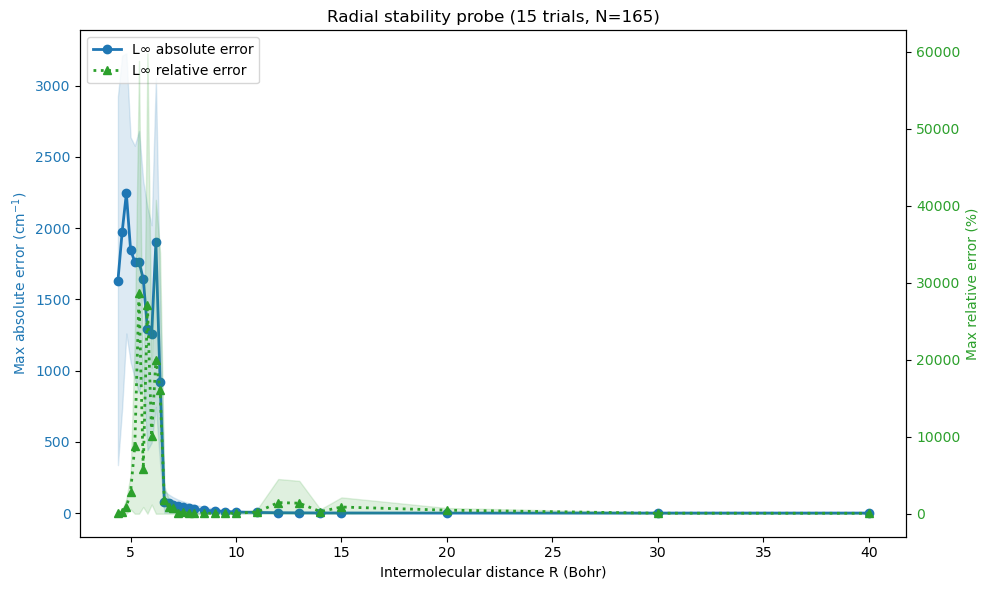

Radial stability probe: N = 205, 15 random trials
R        | Eff. rank  | Max abs err (cm^-1)        | Max rel err (%)       
------------------------------------------------------------------------------------
4.40     | 158.0      | 218.95 ± 77.33 | 15.83 ± 9.68
4.60     | 158.0      | 288.61 ± 131.28 | 40.79 ± 30.40
4.80     | 158.0      | 378.58 ± 178.24 | 113.68 ± 92.64
5.00     | 158.0      | 459.64 ± 358.54 | 547.27 ± 565.99
5.20     | 158.0      | 471.71 ± 354.43 | 1630.62 ± 1996.38
5.40     | 158.0      | 516.98 ± 229.12 | 6702.05 ± 6538.35
5.60     | 158.0      | 537.61 ± 331.35 | 1248.44 ± 873.13
5.80     | 158.0      | 447.35 ± 330.68 | 5414.49 ± 4984.60
6.00     | 158.0      | 314.07 ± 216.40 | 3515.62 ± 3251.58
6.20     | 158.0      | 333.95 ± 210.30 | 1793.34 ± 1598.51
6.40     | 158.0      | 145.65 ± 63.94 | 2073.39 ± 1989.95
6.60     | 158.0      | 1.21 ± 0.67 | 46.13 ± 42.98
6.80     | 158.0      | 0.88 ± 0.51 | 9.45 ± 13.49
7.00     | 158.0      | 0.72 ± 0.40 | 23.73

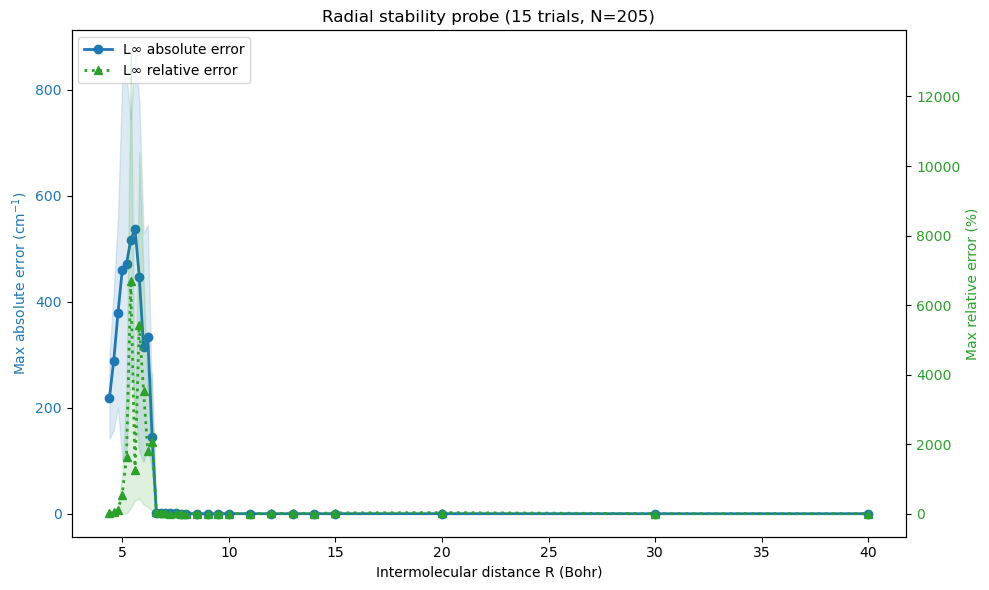

Radial stability probe: N = 245, 15 random trials
R        | Eff. rank  | Max abs err (cm^-1)        | Max rel err (%)       
------------------------------------------------------------------------------------
4.40     | 158.0      | 112.07 ± 30.12 | 9.20 ± 5.04
4.60     | 158.0      | 121.95 ± 40.56 | 19.43 ± 10.59
4.80     | 158.0      | 152.56 ± 77.59 | 53.80 ± 40.76
5.00     | 158.0      | 165.70 ± 87.62 | 254.35 ± 214.06
5.20     | 158.0      | 133.22 ± 49.26 | 318.55 ± 338.51
5.40     | 158.0      | 150.17 ± 67.24 | 1237.64 ± 655.67
5.60     | 158.0      | 199.58 ± 72.92 | 624.11 ± 728.92
5.80     | 158.0      | 120.46 ± 45.11 | 2052.34 ± 3059.39
6.00     | 158.0      | 97.69 ± 35.06 | 1350.97 ± 1226.26
6.20     | 158.0      | 104.35 ± 74.95 | 846.64 ± 934.48
6.40     | 158.0      | 60.15 ± 31.25 | 823.04 ± 826.42
6.60     | 158.0      | 0.39 ± 0.17 | 18.08 ± 14.88
6.80     | 158.0      | 0.27 ± 0.07 | 2.77 ± 2.70
7.00     | 158.0      | 0.26 ± 0.10 | 23.21 ± 30.03
7.25     | 15

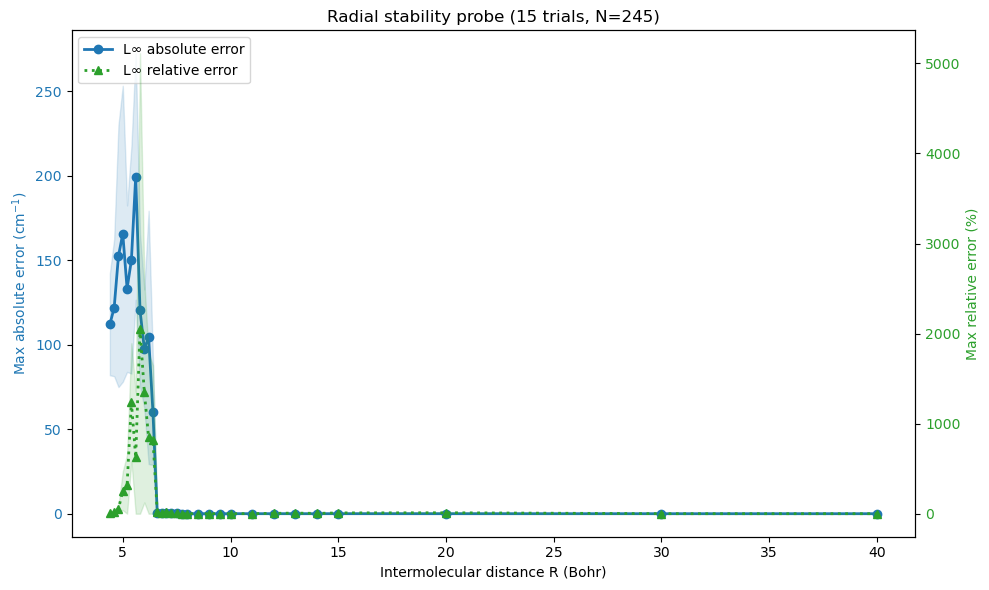

Radial stability probe: N = 285, 15 random trials
R        | Eff. rank  | Max abs err (cm^-1)        | Max rel err (%)       
------------------------------------------------------------------------------------
4.40     | 158.0      | 86.11 ± 24.06 | 8.37 ± 5.70
4.60     | 158.0      | 83.14 ± 23.00 | 15.80 ± 8.05
4.80     | 158.0      | 83.47 ± 28.99 | 23.14 ± 19.93
5.00     | 158.0      | 116.28 ± 52.39 | 128.89 ± 133.72
5.20     | 158.0      | 100.93 ± 28.28 | 299.97 ± 429.05
5.40     | 158.0      | 107.51 ± 45.42 | 918.39 ± 869.85
5.60     | 158.0      | 119.03 ± 65.22 | 272.58 ± 228.52
5.80     | 158.0      | 79.80 ± 42.21 | 427.06 ± 193.62
6.00     | 158.0      | 66.00 ± 21.32 | 1025.88 ± 1007.30
6.20     | 158.0      | 52.41 ± 17.11 | 543.15 ± 673.45
6.40     | 158.0      | 35.71 ± 8.31 | 387.88 ± 608.94
6.60     | 158.0      | 0.23 ± 0.11 | 8.85 ± 7.63
6.80     | 158.0      | 0.19 ± 0.08 | 2.55 ± 2.81
7.00     | 158.0      | 0.16 ± 0.06 | 13.67 ± 18.13
7.25     | 158.0      | 0

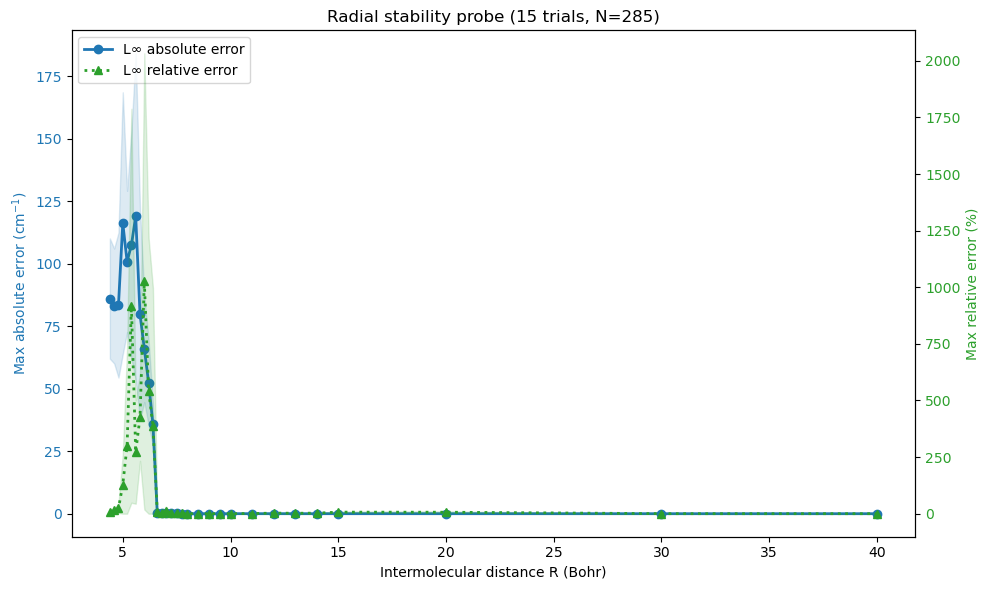

In [8]:
def probe_radial_stability_multiseed(df, basis, test_sizes=(165, 205, 245, 285), n_trials=15):
    radii = sorted(df["R"].unique())
    seeds = list(range(100, 100*(n_trials + 1), 100))

    for N in test_sizes:
        print("=" * 84)
        print(f"Radial stability probe: N = {N}, {n_trials} random trials")
        print("=" * 84)
        print(f"{'R':<8} | {'Eff. rank':<10} | {'Max abs err (cm^-1)':<26} | {'Max rel err (%)':<22}")
        print("-" * 84)

        rows = []
        for R in radii:
            df_r = get_r_slice(df, R)
            if len(df_r) <= N:
                continue

            ranks, abs_errs, rel_errs = [], [], []
            for seed in seeds:
                df_train = df_r.sample(n=N, random_state=seed)
                df_test = df_r.drop(df_train.index)

                coeffs, M_train = fit_coefficients(df_train, basis, target_col="V_scaled")
                rank, _, _ = svd_rank_and_condition(M_train)
                ranks.append(rank)

                pred = predict_from_df(df_test, basis, coeffs)
                truth = df_test["V_scaled"].values
                mask = df_test["V"].values < 5000.0

                if np.any(mask):
                    abs_band = np.abs(pred[mask] - truth[mask])
                    rel_band = relative_error_percent(pred[mask], truth[mask])
                    abs_errs.append(np.max(abs_band))
                    rel_errs.append(np.max(rel_band))
                else:
                    abs_errs.append(0.0)
                    rel_errs.append(0.0)

            row = {
                "R": R,
                "rank_mean": np.mean(ranks),
                "abs_mean": np.mean(abs_errs),
                "abs_std": np.std(abs_errs),
                "rel_mean": np.mean(rel_errs),
                "rel_std": np.std(rel_errs),
            }
            rows.append(row)
            print(f"{R:<8.2f} | {row['rank_mean']:<10.1f} | {row['abs_mean']:.2f} ± {row['abs_std']:.2f} | {row['rel_mean']:.2f} ± {row['rel_std']:.2f}")

        res = pd.DataFrame(rows)
        fig, ax1 = plt.subplots(figsize=(10, 6))
        ax1.plot(res["R"], res["abs_mean"], marker="o", linewidth=2, color="tab:blue", label="L∞ absolute error")
        ax1.fill_between(res["R"], res["abs_mean"] - res["abs_std"], res["abs_mean"] + res["abs_std"], color="tab:blue", alpha=0.15)
        ax1.set_xlabel("Intermolecular distance R (Bohr)")
        ax1.set_ylabel("Max absolute error (cm$^{-1}$)", color="tab:blue")
        ax1.tick_params(axis="y", labelcolor="tab:blue")

        ax2 = ax1.twinx()
        rel_lower = np.clip(res["rel_mean"] - res["rel_std"], 0, None)
        rel_upper = res["rel_mean"] + res["rel_std"]
        ax2.plot(res["R"], res["rel_mean"], marker="^", linestyle=":", linewidth=2, color="tab:green", label="L∞ relative error")
        ax2.fill_between(res["R"], rel_lower, rel_upper, color="tab:green", alpha=0.15)
        ax2.set_ylabel("Max relative error (%)", color="tab:green")
        ax2.tick_params(axis="y", labelcolor="tab:green")

        lines = ax1.lines + ax2.lines
        labels = [line.get_label() for line in lines]
        ax1.legend(lines, labels, loc="upper left")
        ax1.set_title(f"Radial stability probe ({n_trials} trials, N={N})")
        plt.tight_layout()
        plt.show()


probe_radial_stability_multiseed(df_all, basis_indices)


## Cell 9 — Condition number vs held-out error

This is a more focused saturation test at **R = 4.4 Bohr**. It tracks whether the matrix conditioning and the held-out error improve together as more points are used.

The useful conclusion is a soft threshold: **N = 165** lies inside an unstable region, while the fit becomes much more reproducible around **N = 200–250** and continues improving with more points.


In [9]:
def track_condition_vs_error_multiseed(df, basis, target_R=4.40, n_trials=5):
    print(f"=== Condition number vs error ({n_trials} trials, R = {target_R}) ===")
    df_r = get_r_slice(df, target_R)
    N_values = [100, 125, 150, 175, 200, 225, 250, 275, 300, 350, 400]
    seeds = [42 + 19*i for i in range(n_trials)]

    print(f"{'N points':<10} | {'Cond number':<30} | {'Max L_inf abs err (cm^-1)':<32}")
    print("-" * 82)

    for N in N_values:
        conds, errors = [], []
        for seed in seeds:
            df_train = df_r.sample(n=N, random_state=seed)
            df_test = df_r.drop(df_train.index)

            coeffs, M_train = fit_coefficients(df_train, basis, target_col="V_scaled")
            _, cond, _ = svd_rank_and_condition(M_train)
            conds.append(cond)

            pred = predict_from_df(df_test, basis, coeffs)
            mask = df_test["V"].values < 5000.0
            if np.any(mask):
                errors.append(np.max(np.abs(pred[mask] - df_test["V_scaled"].values[mask])))
            else:
                errors.append(0.0)

        print(f"{N:<10} | {np.mean(conds):.2e} ± {np.std(conds):.2e} | {np.mean(errors):.2f} ± {np.std(errors):.2f}")


track_condition_vs_error_multiseed(df_all, basis_indices)


=== Condition number vs error (5 trials, R = 4.4) ===
N points   | Cond number                    | Max L_inf abs err (cm^-1)       
----------------------------------------------------------------------------------
100        | 1.03e+03 ± 1.02e+03 | 4854.39 ± 573.39
125        | 8.46e+03 ± 1.07e+04 | 5176.36 ± 803.00
150        | 3.54e+05 ± 3.03e+05 | 3015.39 ± 1053.04
175        | 1.08e+04 ± 9.83e+03 | 992.78 ± 891.71
200        | 1.11e+03 ± 6.33e+02 | 237.38 ± 124.71
225        | 4.32e+02 ± 1.91e+02 | 176.91 ± 104.07
250        | 2.83e+02 ± 1.16e+02 | 158.14 ± 85.80
275        | 1.86e+02 ± 9.62e+01 | 128.12 ± 58.56
300        | 1.21e+02 ± 5.65e+01 | 75.70 ± 25.09
350        | 8.13e+01 ± 5.22e+01 | 48.81 ± 11.18
400        | 5.39e+01 ± 6.56e+00 | 39.12 ± 10.02


## Cell 10 — Representation error: full basis, truncation, and log weighting

Earlier, the truncated basis looked better at **N = 165** because the full basis was data-starved. This cell repeats the comparison at **N = 400**, where the full basis is much better constrained.

This cell also tests log-weighted least squares. In this notebook version, the target values are still the switched/scaled energies. The raw, no-switching benchmark is tested later in Epilogue 1.


In [10]:
def fit_log_weighted(df_train, basis, target_col="V_scaled", rcond=LSTSQ_RCOND):
    """Least squares with lower-energy points weighted more heavily."""
    M = build_design_matrix(df_train, basis)
    y = df_train[target_col].values
    weights = 1.0 / np.log1p(np.abs(y) + 1.0)
    sqrt_w = np.sqrt(weights)
    coeffs, *_ = np.linalg.lstsq(M * sqrt_w[:, None], y * sqrt_w, rcond=rcond)
    return coeffs


def test_representation_error_multiseed(df, full_basis, target_R=4.40, train_N=400, n_trials=5):
    print(f"=== Representation error test ({n_trials} trials, R = {target_R}, N = {train_N}) ===")
    df_r = get_r_slice(df, target_R)
    basis_trunc = truncated_basis(full_basis)
    seeds = [42 + 23*i for i in range(n_trials)]

    errors = {"global": [], "trunc": [], "log": []}
    for seed in seeds:
        df_train = df_r.sample(n=train_N, random_state=seed)
        df_test = df_r.drop(df_train.index)
        y_test = df_test["V_scaled"].values
        mask = df_test["V"].values < 5000.0

        coeffs_global, _ = fit_coefficients(df_train, full_basis, target_col="V_scaled")
        coeffs_trunc, _ = fit_coefficients(df_train, basis_trunc, target_col="V_scaled")
        coeffs_log = fit_log_weighted(df_train, full_basis, target_col="V_scaled")

        preds = {
            "global": predict_from_df(df_test, full_basis, coeffs_global),
            "trunc": predict_from_df(df_test, basis_trunc, coeffs_trunc),
            "log": predict_from_df(df_test, full_basis, coeffs_log),
        }

        for name, pred in preds.items():
            errors[name].append(np.max(np.abs(pred[mask] - y_test[mask])))

    print(f"{'Model':<32} | {'Max L_inf abs err (cm^-1)':<28}")
    print("-" * 68)
    labels = {
        "global": "Full basis, raw LS",
        "trunc": "Truncated basis, raw LS",
        "log": "Full basis, log-weighted LS",
    }
    for key in ["global", "trunc", "log"]:
        print(f"{labels[key]:<32} | {np.mean(errors[key]):.2f} ± {np.std(errors[key]):.2f}")


test_representation_error_multiseed(df_all, basis_indices)


=== Representation error test (5 trials, R = 4.4, N = 400) ===
Model                            | Max L_inf abs err (cm^-1)   
--------------------------------------------------------------------
Full basis, raw LS               | 47.03 ± 19.96
Truncated basis, raw LS          | 244.18 ± 60.98
Full basis, log-weighted LS      | 47.11 ± 20.22


## Cell 11 — Error distribution by energy regime

A single global error number can hide the most important issue: the uniform grid has very few validation points in the physically important transition region at **R = 4.4 Bohr**.

This cell breaks the held-out error into energy bands using the scaled energy. It shows where the fit is being tested and where the grid is nearly blind.


In [11]:
def probe_error_distribution_multiseed(df, full_basis, target_R=4.40, train_N=400, n_trials=5):
    print(f"=== Error distribution by energy regime ({n_trials} trials, R = {target_R}, N = {train_N}) ===")
    df_r = get_r_slice(df, target_R)
    seeds = [42 + 29*i for i in range(n_trials)]

    regimes = [
        ("Deep well / minimum", 0.0, 100.0),
        ("Transition / low repulsion", 100.0, 1000.0),
        ("Mid repulsive wall", 1000.0, 3000.0),
        ("High wall before ceiling", 3000.0, 4999.0),
    ]
    results = {name: {"pts": [], "abs": [], "rel": []} for name, _, _ in regimes}

    for seed in seeds:
        df_train = df_r.sample(n=train_N, random_state=seed)
        df_test = df_r.drop(df_train.index)
        coeffs, _ = fit_coefficients(df_train, full_basis, target_col="V_scaled")
        pred = predict_from_df(df_test, full_basis, coeffs)
        truth = df_test["V_scaled"].values
        abs_err = np.abs(pred - truth)

        for name, low, high in regimes:
            mask = (truth >= low) & (truth < high)
            pts = int(np.sum(mask))
            results[name]["pts"].append(pts)
            if pts:
                results[name]["abs"].append(np.max(abs_err[mask]))
                results[name]["rel"].append(np.max(relative_error_percent(pred[mask], truth[mask])))
            else:
                results[name]["abs"].append(0.0)
                results[name]["rel"].append(0.0)

    print(f"{'Energy regime':<30} | {'Test pts':<18} | {'Max abs err':<22} | {'Max rel err (%)':<18}")
    print("-" * 96)
    for name, _, _ in regimes:
        r = results[name]
        print(
            f"{name:<30} | "
            f"{np.mean(r['pts']):.1f} ± {np.std(r['pts']):.1f} | "
            f"{np.mean(r['abs']):.2f} ± {np.std(r['abs']):.2f} | "
            f"{np.mean(r['rel']):.2f} ± {np.std(r['rel']):.2f}"
        )


probe_error_distribution_multiseed(df_all, basis_indices)


=== Error distribution by energy regime (5 trials, R = 4.4, N = 400) ===
Energy regime                  | Test pts           | Max abs err            | Max rel err (%)   
------------------------------------------------------------------------------------------------
Deep well / minimum            | 0.0 ± 0.0 | 0.00 ± 0.00 | 0.00 ± 0.00
Transition / low repulsion     | 2.0 ± 0.6 | 19.85 ± 7.39 | 2.23 ± 0.75
Mid repulsive wall             | 21.4 ± 3.9 | 30.67 ± 14.52 | 1.91 ± 0.55
High wall before ceiling       | 76.6 ± 3.7 | 42.99 ± 30.56 | 1.31 ± 0.97


## Cell 12 — Raw least squares vs log-weighted least squares by regime

If the transition region is underperforming, one possible fix is to weight lower energies more heavily. This cell compares ordinary least squares to log-weighted least squares by energy band.

The main result is that log weighting barely changes the error distribution here. That suggests the problem is not just optimizer priority; the grid is missing enough information in the relevant region.


In [12]:
def compare_weighting_distributions(df, full_basis, target_R=4.40, train_N=400):
    print(f"=== Weighting strategy audit (R = {target_R}, N = {train_N}) ===")
    df_r = get_r_slice(df, target_R)
    df_train = df_r.sample(n=train_N, random_state=42)
    df_test = df_r.drop(df_train.index)

    coeffs_raw, _ = fit_coefficients(df_train, full_basis, target_col="V_scaled")
    coeffs_log = fit_log_weighted(df_train, full_basis, target_col="V_scaled")

    pred_raw = predict_from_df(df_test, full_basis, coeffs_raw)
    pred_log = predict_from_df(df_test, full_basis, coeffs_log)
    truth = df_test["V_scaled"].values

    regimes = [
        ("Transition (<1000)", truth < 1000.0),
        ("Mid wall (1000-3000)", (truth >= 1000.0) & (truth < 3000.0)),
        ("High wall (3000-4999)", (truth >= 3000.0) & (truth < 4999.0)),
    ]

    print(f"{'Energy regime':<25} | {'Pts':<4} | {'Raw rel (%)':<13} | {'Log rel (%)':<13} | {'Raw abs':<10} | {'Log abs'}")
    print("-" * 92)
    for name, mask in regimes:
        pts = int(np.sum(mask))
        if pts:
            raw_abs = np.max(np.abs(pred_raw[mask] - truth[mask]))
            log_abs = np.max(np.abs(pred_log[mask] - truth[mask]))
            raw_rel = np.max(relative_error_percent(pred_raw[mask], truth[mask]))
            log_rel = np.max(relative_error_percent(pred_log[mask], truth[mask]))
        else:
            raw_abs = log_abs = raw_rel = log_rel = 0.0
        print(f"{name:<25} | {pts:<4} | {raw_rel:<13.2f} | {log_rel:<13.2f} | {raw_abs:<10.2f} | {log_abs:.2f}")


compare_weighting_distributions(df_all, basis_indices)


=== Weighting strategy audit (R = 4.4, N = 400) ===
Energy regime             | Pts  | Raw rel (%)   | Log rel (%)   | Raw abs    | Log abs
--------------------------------------------------------------------------------------------
Transition (<1000)        | 2    | 2.79          | 2.73          | 25.42      | 24.85
Mid wall (1000-3000)      | 17   | 2.72          | 2.72          | 55.46      | 55.56
High wall (3000-4999)     | 81   | 1.08          | 1.09          | 38.43      | 38.54


## Cell 13 — Uniform grid efficiency audit

This is the main grid-design diagnostic. It counts where the 500 uniform angular points actually land in raw-energy space.

At **R = 4.4 Bohr**, most points are in the very high-energy wall, while only a small fraction are in the transition region. Around **R = 6.4–6.6 Bohr**, the distribution becomes much more physically useful, matching the radial stability results.


In [13]:
def audit_grid_distribution(df, target_R=4.40):
    df_r = get_r_slice(df, target_R)
    raw_V = df_r["V"].values
    bins = [
        ("Deep well (<100)", raw_V < 100.0),
        ("Transition (100-1000)", (raw_V >= 100.0) & (raw_V < 1000.0)),
        ("Mid wall (1000-5000)", (raw_V >= 1000.0) & (raw_V < 5000.0)),
        ("Extreme wall (5000-10000)", (raw_V >= 5000.0) & (raw_V < 10000.0)),
        ("Infinite wall (>10000)", raw_V >= 10000.0),
    ]

    print(f"=== Uniform grid efficiency audit (R = {target_R}) ===")
    print(f"Total available grid points: {len(raw_V)}")
    print(f"{'Physical regime (cm^-1)':<30} | {'Points':<8} | {'% of total':<10}")
    print("-" * 60)
    for name, mask in bins:
        n = int(np.sum(mask))
        print(f"{name:<30} | {n:<8} | {100*n/len(raw_V):<10.1f}")
    print()


audit_grid_distribution(df_all, target_R=4.40)
audit_grid_distribution(df_all, target_R=6.40)
audit_grid_distribution(df_all, target_R=6.60)


=== Uniform grid efficiency audit (R = 4.4) ===
Total available grid points: 500
Physical regime (cm^-1)        | Points   | % of total
------------------------------------------------------------
Deep well (<100)               | 0        | 0.0       
Transition (100-1000)          | 13       | 2.6       
Mid wall (1000-5000)           | 166      | 33.2      
Extreme wall (5000-10000)      | 64       | 12.8      
Infinite wall (>10000)         | 257      | 51.4      

=== Uniform grid efficiency audit (R = 6.4) ===
Total available grid points: 500
Physical regime (cm^-1)        | Points   | % of total
------------------------------------------------------------
Deep well (<100)               | 233      | 46.6      
Transition (100-1000)          | 166      | 33.2      
Mid wall (1000-5000)           | 101      | 20.2      
Extreme wall (5000-10000)      | 0        | 0.0       
Infinite wall (>10000)         | 0        | 0.0       

=== Uniform grid efficiency audit (R = 6.6) ===
Total 

## Interim conclusions from Cells 1–13

The short-range failure appears to be mostly a sampling/information problem, not a simple failure of the 158-term basis.

- At **R = 4.4 Bohr**, a uniform angular grid spends much of its budget in very high-energy configurations.
- Sparse fits with **N = 165** underconstrain the full 158-term basis and create unstable local oscillations.
- Truncation helps under sparse sampling because it reduces variance, but it is not a physically convincing solution at short range.
- Adding points helps, but uniform sampling remains inefficient because many extra points still land in the high-energy wall.
- The key next question is not only “how many points?” but “where do those points need to be for the short-range fit to be safe below roughly 4000–5000 cm⁻¹?”


# Epilogue 1 — What happens without the switching function?

The previous diagnostics use the current switched/scaled target. Laurent and Prajwal asked whether the switching function itself might be part of the problem.

The cells below use raw, unscaled **V** as the fit target. The purpose is not to declare switching good or bad, but to establish a no-switching baseline.


Raw-potential radial stability probe: N = 165, 15 random trials
R        | Eff. rank  | Max abs err (cm^-1)        | Max rel err (%)       
----------------------------------------------------------------------------------------
4.40     | 156.9      | 6747.74 ± 3991.53 | 454.62 ± 279.99
4.60     | 156.9      | 3412.07 ± 1942.49 | 391.24 ± 229.89
4.80     | 156.9      | 1942.79 ± 1450.37 | 536.97 ± 352.04
5.00     | 156.9      | 1171.91 ± 1042.80 | 1367.00 ± 1023.08
5.20     | 156.9      | 744.31 ± 777.07 | 1731.15 ± 1760.94
5.40     | 156.9      | 482.01 ± 566.09 | 7942.91 ± 10576.05
5.60     | 156.9      | 315.55 ± 400.36 | 1205.64 ± 1829.94
5.80     | 156.9      | 215.43 ± 275.74 | 18529.40 ± 56098.11
6.00     | 156.9      | 154.31 ± 188.00 | 1136.20 ± 1659.91
6.20     | 156.9      | 119.60 ± 133.39 | 1022.62 ± 1728.51
6.40     | 156.9      | 97.00 ± 98.60 | 1214.37 ± 1817.52
6.60     | 156.9      | 80.16 ± 76.73 | 1716.89 ± 1837.94
6.80     | 156.9      | 67.65 ± 63.76 | 856.72 ± 1

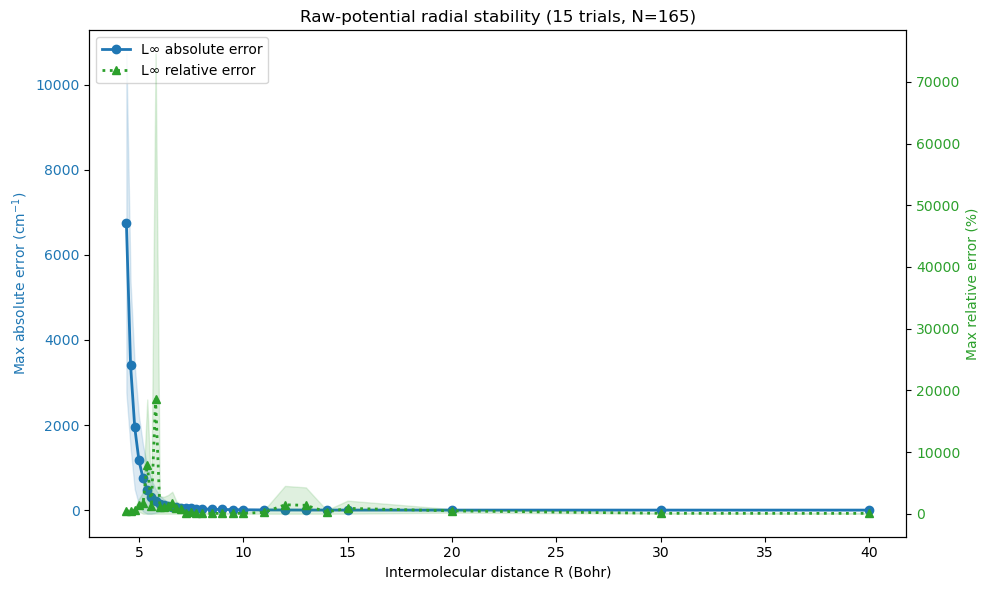

Raw-potential radial stability probe: N = 205, 15 random trials
R        | Eff. rank  | Max abs err (cm^-1)        | Max rel err (%)       
----------------------------------------------------------------------------------------
4.40     | 158.0      | 573.74 ± 288.58 | 39.04 ± 28.81
4.60     | 158.0      | 243.78 ± 125.00 | 31.40 ± 23.48
4.80     | 158.0      | 110.24 ± 52.25 | 37.35 ± 29.52
5.00     | 158.0      | 50.51 ± 24.76 | 92.27 ± 81.99
5.20     | 158.0      | 23.10 ± 12.74 | 86.81 ± 103.21
5.40     | 158.0      | 10.92 ± 6.93 | 170.49 ± 184.46
5.60     | 158.0      | 5.84 ± 3.77 | 19.61 ± 15.46
5.80     | 158.0      | 3.60 ± 2.39 | 70.77 ± 85.98
6.00     | 158.0      | 2.61 ± 1.61 | 26.01 ± 25.75
6.20     | 158.0      | 2.09 ± 1.15 | 18.22 ± 17.55
6.40     | 158.0      | 1.63 ± 0.90 | 22.93 ± 20.95
6.60     | 158.0      | 1.21 ± 0.67 | 46.13 ± 42.98
6.80     | 158.0      | 0.88 ± 0.51 | 9.45 ± 13.49
7.00     | 158.0      | 0.72 ± 0.40 | 23.73 ± 29.30
7.25     | 158.0      | 0

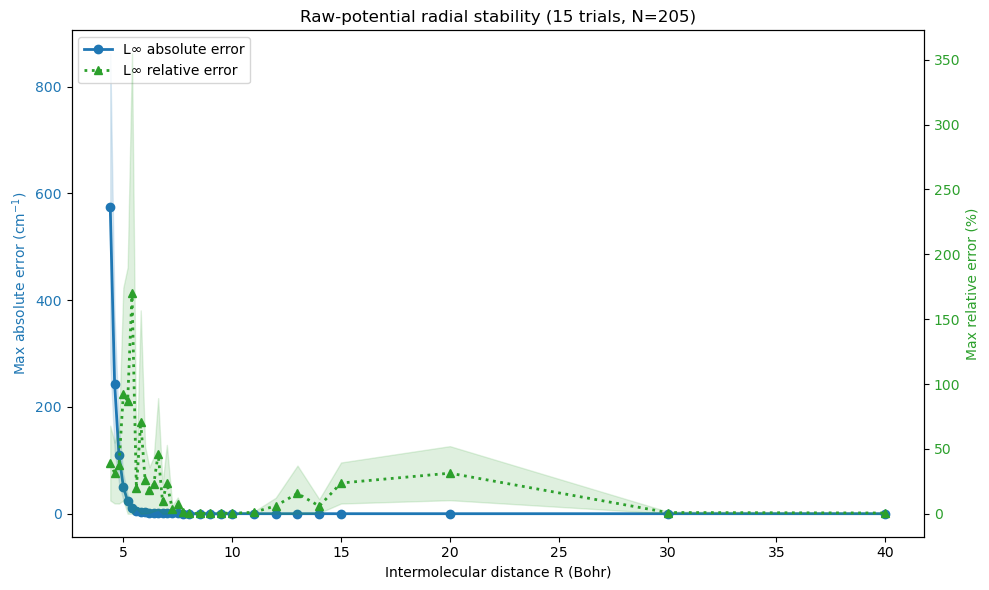

Raw-potential radial stability probe: N = 245, 15 random trials
R        | Eff. rank  | Max abs err (cm^-1)        | Max rel err (%)       
----------------------------------------------------------------------------------------
4.40     | 158.0      | 153.23 ± 103.56 | 8.94 ± 6.46
4.60     | 158.0      | 62.56 ± 43.09 | 6.67 ± 4.50
4.80     | 158.0      | 27.97 ± 18.62 | 8.40 ± 6.22
5.00     | 158.0      | 12.92 ± 8.72 | 15.95 ± 13.53
5.20     | 158.0      | 5.97 ± 4.14 | 16.28 ± 13.11
5.40     | 158.0      | 2.90 ± 1.90 | 32.47 ± 31.13
5.60     | 158.0      | 1.68 ± 0.91 | 6.00 ± 3.97
5.80     | 158.0      | 1.17 ± 0.50 | 39.20 ± 68.86
6.00     | 158.0      | 0.94 ± 0.33 | 12.54 ± 12.90
6.20     | 158.0      | 0.78 ± 0.31 | 5.90 ± 6.54
6.40     | 158.0      | 0.57 ± 0.27 | 7.07 ± 7.39
6.60     | 158.0      | 0.39 ± 0.17 | 18.08 ± 14.88
6.80     | 158.0      | 0.27 ± 0.07 | 2.77 ± 2.70
7.00     | 158.0      | 0.26 ± 0.10 | 23.21 ± 30.03
7.25     | 158.0      | 0.23 ± 0.12 | 2.43 ± 2.6

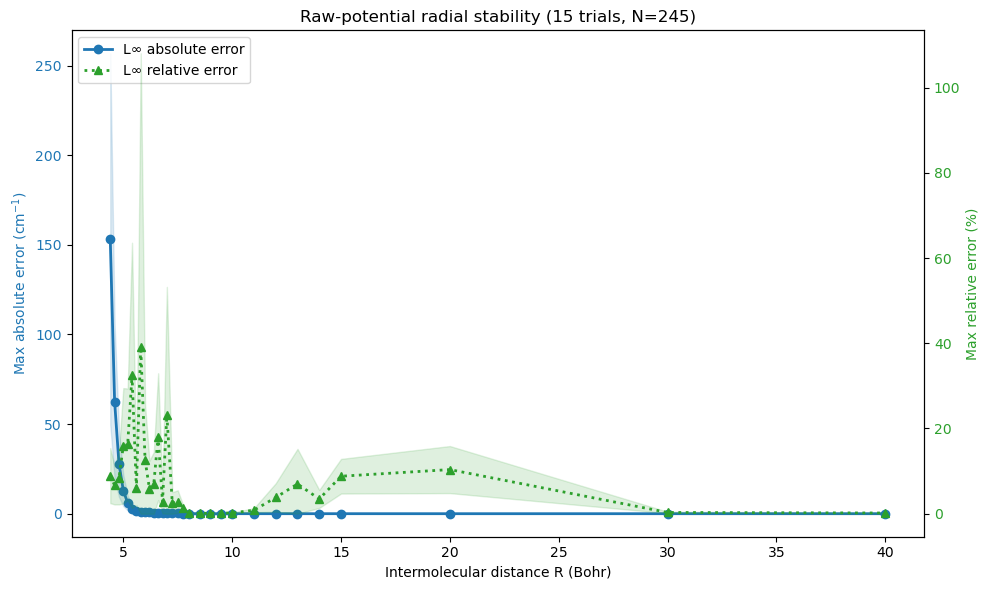

Raw-potential radial stability probe: N = 285, 15 random trials
R        | Eff. rank  | Max abs err (cm^-1)        | Max rel err (%)       
----------------------------------------------------------------------------------------
4.40     | 158.0      | 65.62 ± 71.91 | 5.24 ± 7.71
4.60     | 158.0      | 26.66 ± 28.58 | 3.85 ± 5.83
4.80     | 158.0      | 12.21 ± 11.94 | 4.06 ± 5.85
5.00     | 158.0      | 5.74 ± 5.29 | 10.69 ± 18.04
5.20     | 158.0      | 2.73 ± 2.40 | 8.01 ± 6.75
5.40     | 158.0      | 1.42 ± 1.21 | 23.05 ± 28.62
5.60     | 158.0      | 1.01 ± 0.67 | 4.20 ± 3.24
5.80     | 158.0      | 0.71 ± 0.46 | 17.28 ± 24.24
6.00     | 158.0      | 0.59 ± 0.35 | 9.03 ± 11.38
6.20     | 158.0      | 0.47 ± 0.25 | 2.68 ± 3.82
6.40     | 158.0      | 0.34 ± 0.17 | 5.54 ± 7.79
6.60     | 158.0      | 0.23 ± 0.11 | 8.85 ± 7.63
6.80     | 158.0      | 0.19 ± 0.08 | 2.55 ± 2.81
7.00     | 158.0      | 0.16 ± 0.06 | 13.67 ± 18.13
7.25     | 158.0      | 0.14 ± 0.05 | 1.41 ± 1.10
7.50  

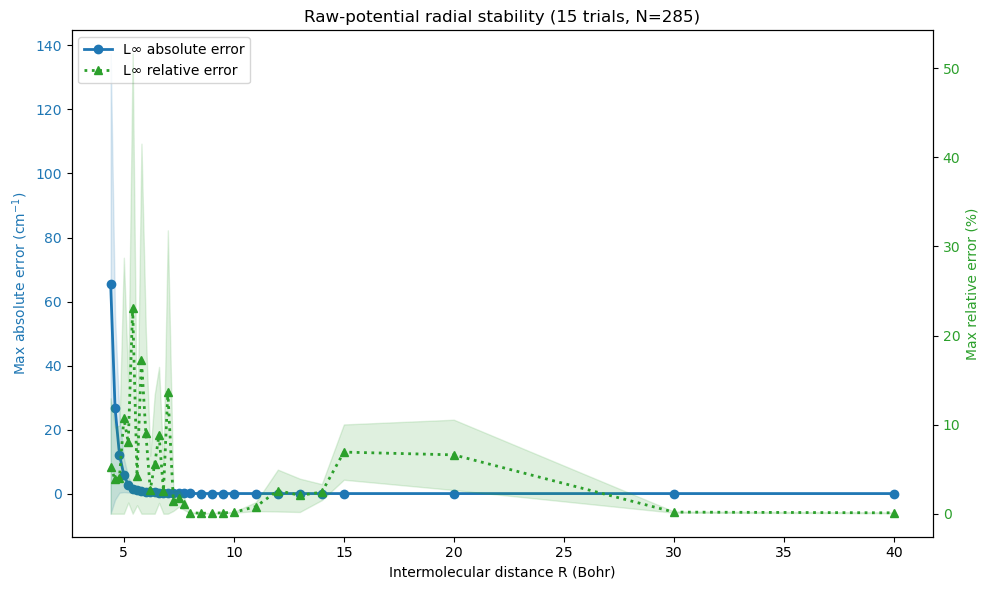

In [14]:
def probe_radial_stability_unscaled_multiseed(df, basis, test_sizes=(165, 205, 245, 285), n_trials=15):
    radii = sorted(df["R"].unique())
    seeds = list(range(100, 100*(n_trials + 1), 100))

    for N in test_sizes:
        print("=" * 88)
        print(f"Raw-potential radial stability probe: N = {N}, {n_trials} random trials")
        print("=" * 88)
        print(f"{'R':<8} | {'Eff. rank':<10} | {'Max abs err (cm^-1)':<26} | {'Max rel err (%)':<22}")
        print("-" * 88)

        rows = []
        for R in radii:
            df_r = get_r_slice(df, R)
            if len(df_r) <= N:
                continue

            ranks, abs_errs, rel_errs = [], [], []
            for seed in seeds:
                df_train = df_r.sample(n=N, random_state=seed)
                df_test = df_r.drop(df_train.index)

                coeffs, M_train = fit_coefficients(df_train, basis, target_col="V")
                rank, _, _ = svd_rank_and_condition(M_train)
                ranks.append(rank)

                pred = predict_from_df(df_test, basis, coeffs)
                truth = df_test["V"].values
                mask = truth < 5000.0

                if np.any(mask):
                    abs_band = np.abs(pred[mask] - truth[mask])
                    rel_band = relative_error_percent(pred[mask], truth[mask])
                    abs_errs.append(np.max(abs_band))
                    rel_errs.append(np.max(rel_band))
                else:
                    abs_errs.append(0.0)
                    rel_errs.append(0.0)

            row = {
                "R": R,
                "rank_mean": np.mean(ranks),
                "abs_mean": np.mean(abs_errs),
                "abs_std": np.std(abs_errs),
                "rel_mean": np.mean(rel_errs),
                "rel_std": np.std(rel_errs),
            }
            rows.append(row)
            print(f"{R:<8.2f} | {row['rank_mean']:<10.1f} | {row['abs_mean']:.2f} ± {row['abs_std']:.2f} | {row['rel_mean']:.2f} ± {row['rel_std']:.2f}")

        res = pd.DataFrame(rows)
        fig, ax1 = plt.subplots(figsize=(10, 6))
        ax1.plot(res["R"], res["abs_mean"], marker="o", linewidth=2, color="tab:blue", label="L∞ absolute error")
        ax1.fill_between(res["R"], res["abs_mean"] - res["abs_std"], res["abs_mean"] + res["abs_std"], color="tab:blue", alpha=0.15)
        ax1.set_xlabel("Intermolecular distance R (Bohr)")
        ax1.set_ylabel("Max absolute error (cm$^{-1}$)", color="tab:blue")
        ax1.tick_params(axis="y", labelcolor="tab:blue")

        ax2 = ax1.twinx()
        rel_lower = np.clip(res["rel_mean"] - res["rel_std"], 0, None)
        rel_upper = res["rel_mean"] + res["rel_std"]
        ax2.plot(res["R"], res["rel_mean"], marker="^", linestyle=":", linewidth=2, color="tab:green", label="L∞ relative error")
        ax2.fill_between(res["R"], rel_lower, rel_upper, color="tab:green", alpha=0.15)
        ax2.set_ylabel("Max relative error (%)", color="tab:green")
        ax2.tick_params(axis="y", labelcolor="tab:green")

        lines = ax1.lines + ax2.lines
        labels = [line.get_label() for line in lines]
        ax1.legend(lines, labels, loc="upper left")
        ax1.set_title(f"Raw-potential radial stability ({n_trials} trials, N={N})")
        plt.tight_layout()
        plt.show()


probe_radial_stability_unscaled_multiseed(df_all, basis_indices)


## Epilogue 1A — Full raw fit using all 500 points

This is the most optimistic raw-potential benchmark: all angular points, full 158-term basis, no switching, no weighting, and no truncation.

It answers: if we give the basis all available information at each radial slice, can it reproduce the raw ab initio surface in the physically relevant region?


=== Full raw-potential baseline: all 500 points per R ===
Model: full 158-term basis
Training/evaluation: all available angular points at each R
Target: raw V, no switching function

R        | N     | Rank   | Cond #       | Max Abs Err     | Max Rel All (%)        | Max Rel <5000 (%)       
-------------------------------------------------------------------------------------------------------------------
4.40     | 500   | 158    | 4.57e+01     | 65.33           | 0.30                   | 0.30                    
4.60     | 500   | 158    | 4.57e+01     | 26.38           | 0.21                   | 0.21                    
4.80     | 500   | 158    | 4.57e+01     | 11.30           | 0.18                   | 0.18                    
5.00     | 500   | 158    | 4.57e+01     | 5.07            | 0.64                   | 0.64                    
5.20     | 500   | 158    | 4.57e+01     | 2.25            | 0.60                   | 0.60                    
5.40     | 500   | 158    | 4.57e+0

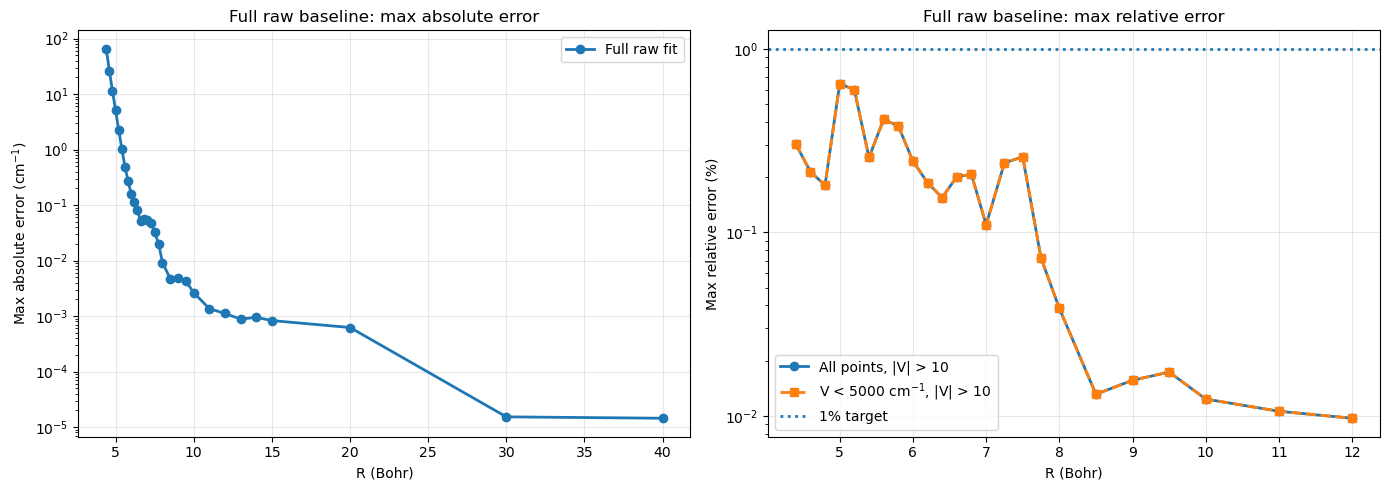

In [15]:
def full_raw_baseline_radial_probe(df, basis, rel_floor=10.0, physical_cap=5000.0, rcond=None, make_plot=True):
    print("=== Full raw-potential baseline: all 500 points per R ===")
    print("Model: full 158-term basis")
    print("Training/evaluation: all available angular points at each R")
    print("Target: raw V, no switching function\n")

    rows = []
    print(
        f"{'R':<8} | {'N':<5} | {'Rank':<6} | {'Cond #':<12} | "
        f"{'Max Abs Err':<15} | {'Max Rel All (%)':<22} | {'Max Rel <5000 (%)':<24}"
    )
    print("-" * 115)

    for R in sorted(df["R"].unique()):
        df_r = get_r_slice(df, R)
        M = build_design_matrix(df_r, basis)
        y = df_r["V"].values

        _, S, _ = np.linalg.svd(M, full_matrices=False)
        rank = int(np.sum(S > 1e-10))
        cond = S[0] / S[-1] if S[-1] > 1e-14 else np.inf

        coeffs, *_ = np.linalg.lstsq(M, y, rcond=rcond)
        pred = M @ coeffs
        abs_err = np.abs(pred - y)

        rel_mask_all = np.abs(y) > rel_floor
        rel_mask_phys = rel_mask_all & (y < physical_cap)

        max_rel_all = 100.0 * np.max(abs_err[rel_mask_all] / np.abs(y[rel_mask_all])) if np.any(rel_mask_all) else np.nan
        max_rel_phys = 100.0 * np.max(abs_err[rel_mask_phys] / np.abs(y[rel_mask_phys])) if np.any(rel_mask_phys) else np.nan

        rows.append({
            "R": R,
            "N": len(df_r),
            "Rank": rank,
            "Cond": cond,
            "MaxAbsErr": np.max(abs_err),
            "MaxRelAll": max_rel_all,
            "MaxRelPhysical": max_rel_phys,
        })

        print(f"{R:<8.2f} | {len(df_r):<5} | {rank:<6} | {cond:<12.2e} | {np.max(abs_err):<15.2f} | {max_rel_all:<22.2f} | {max_rel_phys:<24.2f}")

    results = pd.DataFrame(rows)

    if make_plot:
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        axes[0].plot(results["R"], results["MaxAbsErr"], marker="o", linewidth=2, label="Full raw fit")
        axes[0].set_xlabel("R (Bohr)")
        axes[0].set_ylabel("Max absolute error (cm$^{-1}$)")
        axes[0].set_title("Full raw baseline: max absolute error")
        axes[0].set_yscale("log")
        axes[0].grid(True, alpha=0.3)
        axes[0].legend()

        axes[1].plot(results["R"], results["MaxRelAll"], marker="o", linewidth=2, label=f"All points, |V| > {rel_floor:g}")
        axes[1].plot(results["R"], results["MaxRelPhysical"], marker="s", linewidth=2, linestyle="--", label=f"V < {physical_cap:g} cm$^{{-1}}$, |V| > {rel_floor:g}")
        axes[1].axhline(1.0, linestyle=":", linewidth=2, label="1% target")
        axes[1].set_xlabel("R (Bohr)")
        axes[1].set_ylabel("Max relative error (%)")
        axes[1].set_title("Full raw baseline: max relative error")
        axes[1].set_yscale("log")
        axes[1].grid(True, alpha=0.3)
        axes[1].legend()
        plt.tight_layout()
        plt.show()

    return results


full_raw_results = full_raw_baseline_radial_probe(
    df_all,
    basis_indices,
    rel_floor=10.0,
    physical_cap=5000.0,
    rcond=None,
    make_plot=True,
)


## Epilogue 1B — Raw train/test baseline with 400 training points

This is the “no funny business” generalization benchmark: raw potential, full basis, no switching, no weighting, no truncation, using 400 training points and 100 held-out test points per radial slice.


=== Raw full-basis train/test radial probe (N=400, 10 trials) ===
Target: raw V, no switching function
Evaluation: held-out test points at each R

R        | Train/Test  | Cond #                  | Max Abs Err             | Max Rel All (%)         | Max Rel <5000 (%)      
----------------------------------------------------------------------------------------------------------------------------------
4.40     | 400/100     | 6.05e+01 [4.2e+01, 9.3e+01] | 54.66 [39.24, 64.74] | 1.05 [0.66, 3.01] | 1.05 [0.66, 3.01]
4.60     | 400/100     | 6.05e+01 [4.2e+01, 9.3e+01] | 22.13 [15.63, 27.45] | 0.71 [0.35, 2.13] | 0.71 [0.35, 2.13]
4.80     | 400/100     | 6.05e+01 [4.2e+01, 9.3e+01] | 9.88 [6.75, 11.97] | 0.79 [0.22, 3.27] | 0.79 [0.22, 3.27]
5.00     | 400/100     | 6.05e+01 [4.2e+01, 9.3e+01] | 4.57 [3.02, 5.35] | 1.16 [0.25, 3.09] | 1.16 [0.25, 3.09]
5.20     | 400/100     | 6.05e+01 [4.2e+01, 9.3e+01] | 2.04 [1.37, 2.42] | 1.06 [0.30, 3.18] | 1.06 [0.30, 3.18]
5.40     | 400/100     

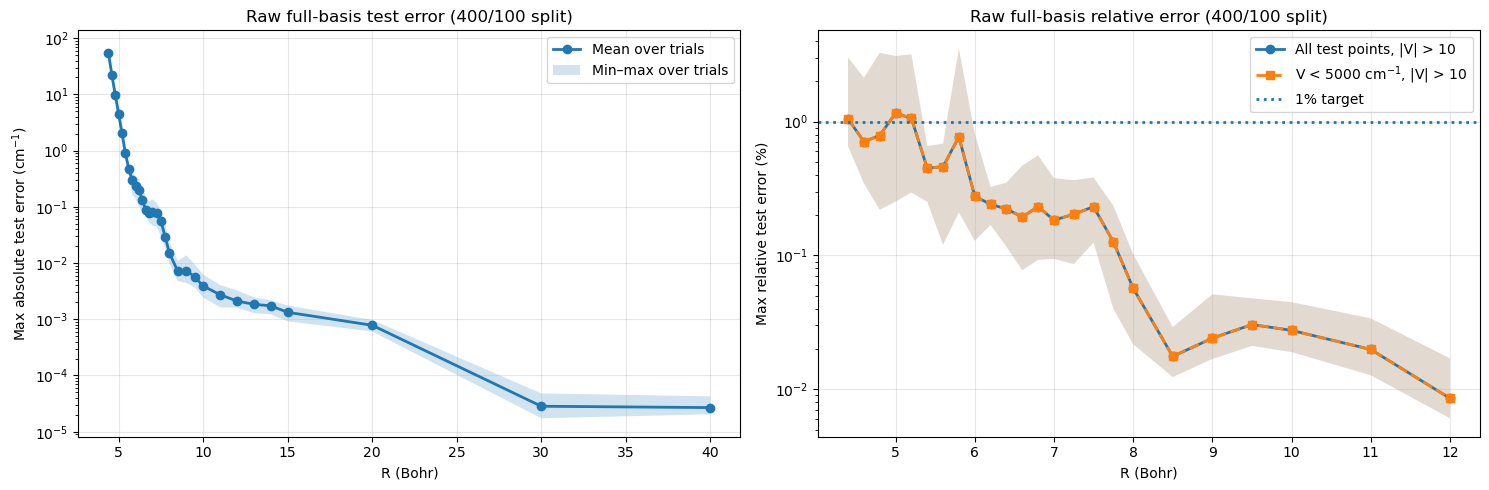

In [16]:
def raw_full_basis_train_test_radial_probe(
    df,
    basis,
    train_N=400,
    n_trials=10,
    rel_floor=10.0,
    physical_cap=5000.0,
    rcond=None,
    make_plot=True,
):
    print(f"=== Raw full-basis train/test radial probe (N={train_N}, {n_trials} trials) ===")
    print("Target: raw V, no switching function")
    print("Evaluation: held-out test points at each R\n")

    seeds = [42 + 31*i for i in range(n_trials)]
    rows = []
    print(
        f"{'R':<8} | {'Train/Test':<11} | {'Cond #':<23} | {'Max Abs Err':<23} | "
        f"{'Max Rel All (%)':<23} | {'Max Rel <5000 (%)':<23}"
    )
    print("-" * 130)

    for R in sorted(df["R"].unique()):
        df_r = get_r_slice(df, R)
        if train_N >= len(df_r):
            raise ValueError(f"train_N={train_N} is too large for R={R}; only {len(df_r)} points available.")

        trial_conds = []
        trial_max_abs = []
        trial_max_rel_all = []
        trial_max_rel_phys = []

        for seed in seeds:
            df_train = df_r.sample(n=train_N, random_state=seed)
            df_test = df_r.drop(df_train.index)

            M_train = build_design_matrix(df_train, basis)
            M_test = build_design_matrix(df_test, basis)
            y_train = df_train["V"].values
            y_test = df_test["V"].values

            _, S, _ = np.linalg.svd(M_train, full_matrices=False)
            trial_conds.append(S[0] / S[-1] if S[-1] > 1e-14 else np.inf)

            coeffs, *_ = np.linalg.lstsq(M_train, y_train, rcond=rcond)
            pred = M_test @ coeffs
            abs_err = np.abs(pred - y_test)
            trial_max_abs.append(np.max(abs_err))

            rel_mask_all = np.abs(y_test) > rel_floor
            rel_mask_phys = rel_mask_all & (y_test < physical_cap)

            trial_max_rel_all.append(100.0 * np.max(abs_err[rel_mask_all] / np.abs(y_test[rel_mask_all])) if np.any(rel_mask_all) else np.nan)
            trial_max_rel_phys.append(100.0 * np.max(abs_err[rel_mask_phys] / np.abs(y_test[rel_mask_phys])) if np.any(rel_mask_phys) else np.nan)

        row = {
            "R": R,
            "TrainN": train_N,
            "TestN": len(df_r) - train_N,
            "CondMean": np.nanmean(trial_conds),
            "CondMin": np.nanmin(trial_conds),
            "CondMax": np.nanmax(trial_conds),
            "MaxAbsMean": np.nanmean(trial_max_abs),
            "MaxAbsMin": np.nanmin(trial_max_abs),
            "MaxAbsMax": np.nanmax(trial_max_abs),
            "MaxRelAllMean": np.nanmean(trial_max_rel_all),
            "MaxRelAllMin": np.nanmin(trial_max_rel_all),
            "MaxRelAllMax": np.nanmax(trial_max_rel_all),
            "MaxRelPhysicalMean": np.nanmean(trial_max_rel_phys),
            "MaxRelPhysicalMin": np.nanmin(trial_max_rel_phys),
            "MaxRelPhysicalMax": np.nanmax(trial_max_rel_phys),
        }
        rows.append(row)

        print(
            f"{R:<8.2f} | {train_N}/{len(df_r) - train_N:<7} | "
            f"{row['CondMean']:.2e} [{row['CondMin']:.1e}, {row['CondMax']:.1e}] | "
            f"{row['MaxAbsMean']:.2f} [{row['MaxAbsMin']:.2f}, {row['MaxAbsMax']:.2f}] | "
            f"{row['MaxRelAllMean']:.2f} [{row['MaxRelAllMin']:.2f}, {row['MaxRelAllMax']:.2f}] | "
            f"{row['MaxRelPhysicalMean']:.2f} [{row['MaxRelPhysicalMin']:.2f}, {row['MaxRelPhysicalMax']:.2f}]"
        )

    results = pd.DataFrame(rows)

    if make_plot:
        fig, axes = plt.subplots(1, 2, figsize=(15, 5))
        axes[0].plot(results["R"], results["MaxAbsMean"], marker="o", linewidth=2, label="Mean over trials")
        axes[0].fill_between(results["R"], results["MaxAbsMin"], results["MaxAbsMax"], alpha=0.2, label="Min–max over trials")
        axes[0].set_xlabel("R (Bohr)")
        axes[0].set_ylabel("Max absolute test error (cm$^{-1}$)")
        axes[0].set_title(f"Raw full-basis test error ({train_N}/100 split)")
        axes[0].set_yscale("log")
        axes[0].grid(True, alpha=0.3)
        axes[0].legend()

        axes[1].plot(results["R"], results["MaxRelAllMean"], marker="o", linewidth=2, label=f"All test points, |V| > {rel_floor:g}")
        axes[1].fill_between(results["R"], results["MaxRelAllMin"], results["MaxRelAllMax"], alpha=0.15)
        axes[1].plot(results["R"], results["MaxRelPhysicalMean"], marker="s", linewidth=2, linestyle="--", label=f"V < {physical_cap:g} cm$^{{-1}}$, |V| > {rel_floor:g}")
        axes[1].fill_between(results["R"], results["MaxRelPhysicalMin"], results["MaxRelPhysicalMax"], alpha=0.15)
        axes[1].axhline(1.0, linestyle=":", linewidth=2, label="1% target")
        axes[1].set_xlabel("R (Bohr)")
        axes[1].set_ylabel("Max relative test error (%)")
        axes[1].set_title(f"Raw full-basis relative error ({train_N}/100 split)")
        axes[1].set_yscale("log")
        axes[1].grid(True, alpha=0.3)
        axes[1].legend()
        plt.tight_layout()
        plt.show()

    return results


raw_full_400_results = raw_full_basis_train_test_radial_probe(
    df_all,
    basis_indices,
    train_N=400,
    n_trials=10,
    rel_floor=10.0,
    physical_cap=5000.0,
    rcond=None,
    make_plot=True,
)


# Epilogue 2 — Ridge/Tikhonov regularization

This cell tests whether soft regularization can suppress sparse-data oscillations without throwing away basis terms. It is a useful check, but it should not be treated as a replacement for missing physical information.


In [17]:
def ridge_coefficients(M, y, alpha):
    """Closed-form ridge solution with no intercept: (MᵀM + αI)c = Mᵀy."""
    if alpha == 0:
        coeffs, *_ = np.linalg.lstsq(M, y, rcond=LSTSQ_RCOND)
        return coeffs
    A = M.T @ M + alpha * np.eye(M.shape[1])
    b = M.T @ y
    return np.linalg.solve(A, b)


def probe_ridge_regularization(df, basis, target_R=4.40, train_N=165):
    print(f"=== Ridge regularization probe (R = {target_R}, N = {train_N}) ===")
    df_r = get_r_slice(df, target_R)
    df_train = df_r.sample(n=train_N, random_state=42)
    df_test = df_r.drop(df_train.index)

    M_train = build_design_matrix(df_train, basis)
    M_test = build_design_matrix(df_test, basis)
    y_train = df_train["V_scaled"].values
    y_test = df_test["V_scaled"].values
    mask = df_test["V"].values < 5000.0

    alphas = [0.0, 1e-6, 1e-4, 1e-2, 1.0, 10.0, 100.0]
    print(f"{'Alpha':<12} | {'Max |coef|':<14} | {'Max abs err below 5000':<25}")
    print("-" * 62)

    for alpha in alphas:
        coeffs = ridge_coefficients(M_train, y_train, alpha)
        pred = M_test @ coeffs
        max_coef = np.max(np.abs(coeffs))
        max_err = np.max(np.abs(pred[mask] - y_test[mask])) if np.any(mask) else 0.0
        print(f"{alpha:<12.1e} | {max_coef:<14.2f} | {max_err:<25.2f}")


probe_ridge_regularization(df_all, basis_indices)


=== Ridge regularization probe (R = 4.4, N = 165) ===
Alpha        | Max |coef|     | Max abs err below 5000   
--------------------------------------------------------------
0.0e+00      | 19887.96       | 1499.84                  
1.0e-06      | 19707.34       | 941.60                   
1.0e-04      | 17905.26       | 3064.53                  
1.0e-02      | 15409.53       | 4494.50                  
1.0e+00      | 10277.35       | 4283.15                  
1.0e+01      | 3892.64        | 3668.43                  
1.0e+02      | 645.65         | 3524.74                  


# Epilogue 3 — Global Checks

These final plots are dense-grid baselines. They are included to avoid the wrong conclusion that the 158-term basis is simply broken.

The first plot uses the current switched/scaled target. The second uses the raw target. Together they show what the full basis can do when it is given all 500 angular points at each radial slice.


=== Global health check: switched/scaled target ===


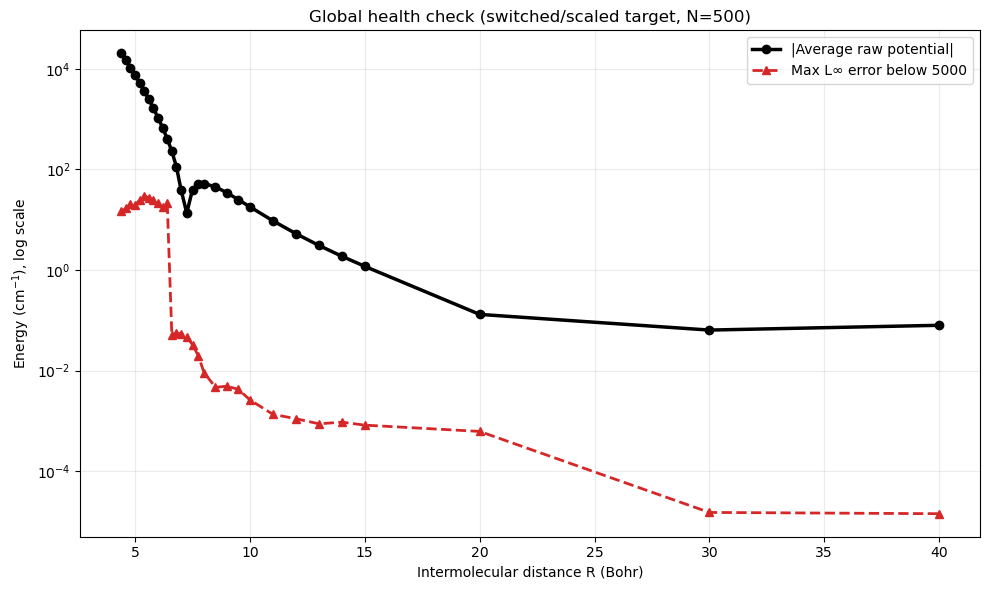

=== Global health check: raw target, no switching ===


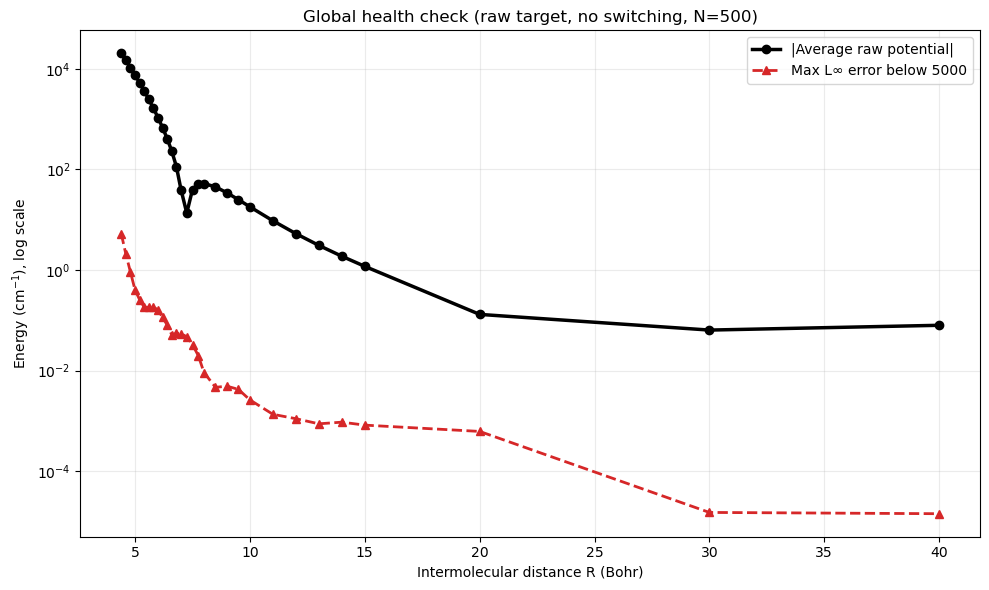

In [18]:
def plot_laurent_global_health(df, basis, target_col="V_scaled", title_suffix="switched target"):
    print(f"=== Global health check: {title_suffix} ===")
    avg_energies, max_errors, valid_radii = [], [], []

    for R in sorted(df["R"].unique()):
        df_r = get_r_slice(df, R)
        coeffs, _ = fit_coefficients(df_r, basis, target_col=target_col)
        pred = predict_from_df(df_r, basis, coeffs)
        truth_raw = df_r["V"].values
        truth_target = df_r[target_col].values
        mask = truth_raw < 5000.0

        if np.any(mask):
            avg_energies.append(abs(np.mean(truth_raw)))
            max_errors.append(np.max(np.abs(pred[mask] - truth_target[mask])))
            valid_radii.append(R)

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.plot(valid_radii, avg_energies, color="black", linewidth=2.5, marker="o", label="|Average raw potential|")
    ax.plot(valid_radii, max_errors, color="tab:red", linewidth=2, marker="^", linestyle="--", label="Max L∞ error below 5000")
    ax.set_yscale("log")
    ax.set_xlabel("Intermolecular distance R (Bohr)")
    ax.set_ylabel("Energy (cm$^{-1}$), log scale")
    ax.set_title(f"Global health check ({title_suffix}, N=500)")
    ax.grid(True, which="both", alpha=0.25)
    ax.legend(loc="upper right")
    plt.tight_layout()
    plt.show()


plot_laurent_global_health(df_all, basis_indices, target_col="V_scaled", title_suffix="switched/scaled target")
plot_laurent_global_health(df_all, basis_indices, target_col="V", title_suffix="raw target, no switching")


## Final interpretation

The notebook supports the following working conclusions:

1. **Short range is genuinely difficult.** At small R, many angular configurations are physically inaccessible, but the fit still needs enough information to represent the accessible boundary correctly.
2. **The full 158-term basis is not the main culprit.** It performs much better when sufficiently constrained.
3. **N = 165 is too sparse for the full basis at R = 4.4 Bohr.** The matrix is fragile and the fit is highly sensitive to which points are selected.
4. **Truncation is a diagnostic, not a final solution.** It reduces variance under sparse sampling but risks removing real short-range angular structure.
5. **The switching function is useful but not sacred.** It protects sparse fits from high-energy wall domination, but it can distort the energy region that needs to be trusted.
6. **The next step is a short-range safety study.** We should quantify which R values and which energy regimes below roughly 4000–5000 cm⁻¹ can be trusted under no switching, current switching, and modified switching/sampling strategies.
